In [1]:
import scanpy as sc
import os
import anndata as ad
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import math
import os
import pickle
from scipy.stats import linregress
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu
import seaborn as sns
from adjustText import adjust_text

# verbosity: errors (0), warnings (1), info (2), hints (3)
sc.settings.set_figure_params(dpi=50, dpi_save=300, facecolor="white", frameon=False, figsize=(5,5))
%matplotlib inline
sc.settings.verbosity = 0


# new data

In [2]:
path='/nfs/team361/ls34/inflow/adata_10ad_spatial_validation2.h5ad'
adata_new=sc.read_h5ad(path)


In [3]:
if path=='/nfs/team361/ls34/inflow/adata_10ad_spatial_validation2.h5ad':
    RENAME = {"MigDC (cDC2)": "MigDC",
         "Treg_LRRC32+": "Treg"
         }
    #adata_5k_baseline=adata_5k
    adata_new.obs["lvl4_annotation"]=adata_new.obs["new_annotation"].map(RENAME).fillna(adata_new.obs["new_annotation"])
    adata_new = adata_new[adata_new.obs["new_annotation"]!="MigDC (cDC1)"]
    adata_new.obs["Sanger patient ID"]=adata_new.obs["sample_id2"]
    adata_new.obs["Timepoint2"]=adata_new.obs["timepoint"]
    adata_new.obs["Responder"]=adata_new.obs["responder"]

    adata_new.obs["lvl5_annotation"]=adata_new.obs["new_annotation"]

/tmp/ipykernel_581881/3906072612.py:8: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_new.obs["Sanger patient ID"]=adata_new.obs["sample_id2"]


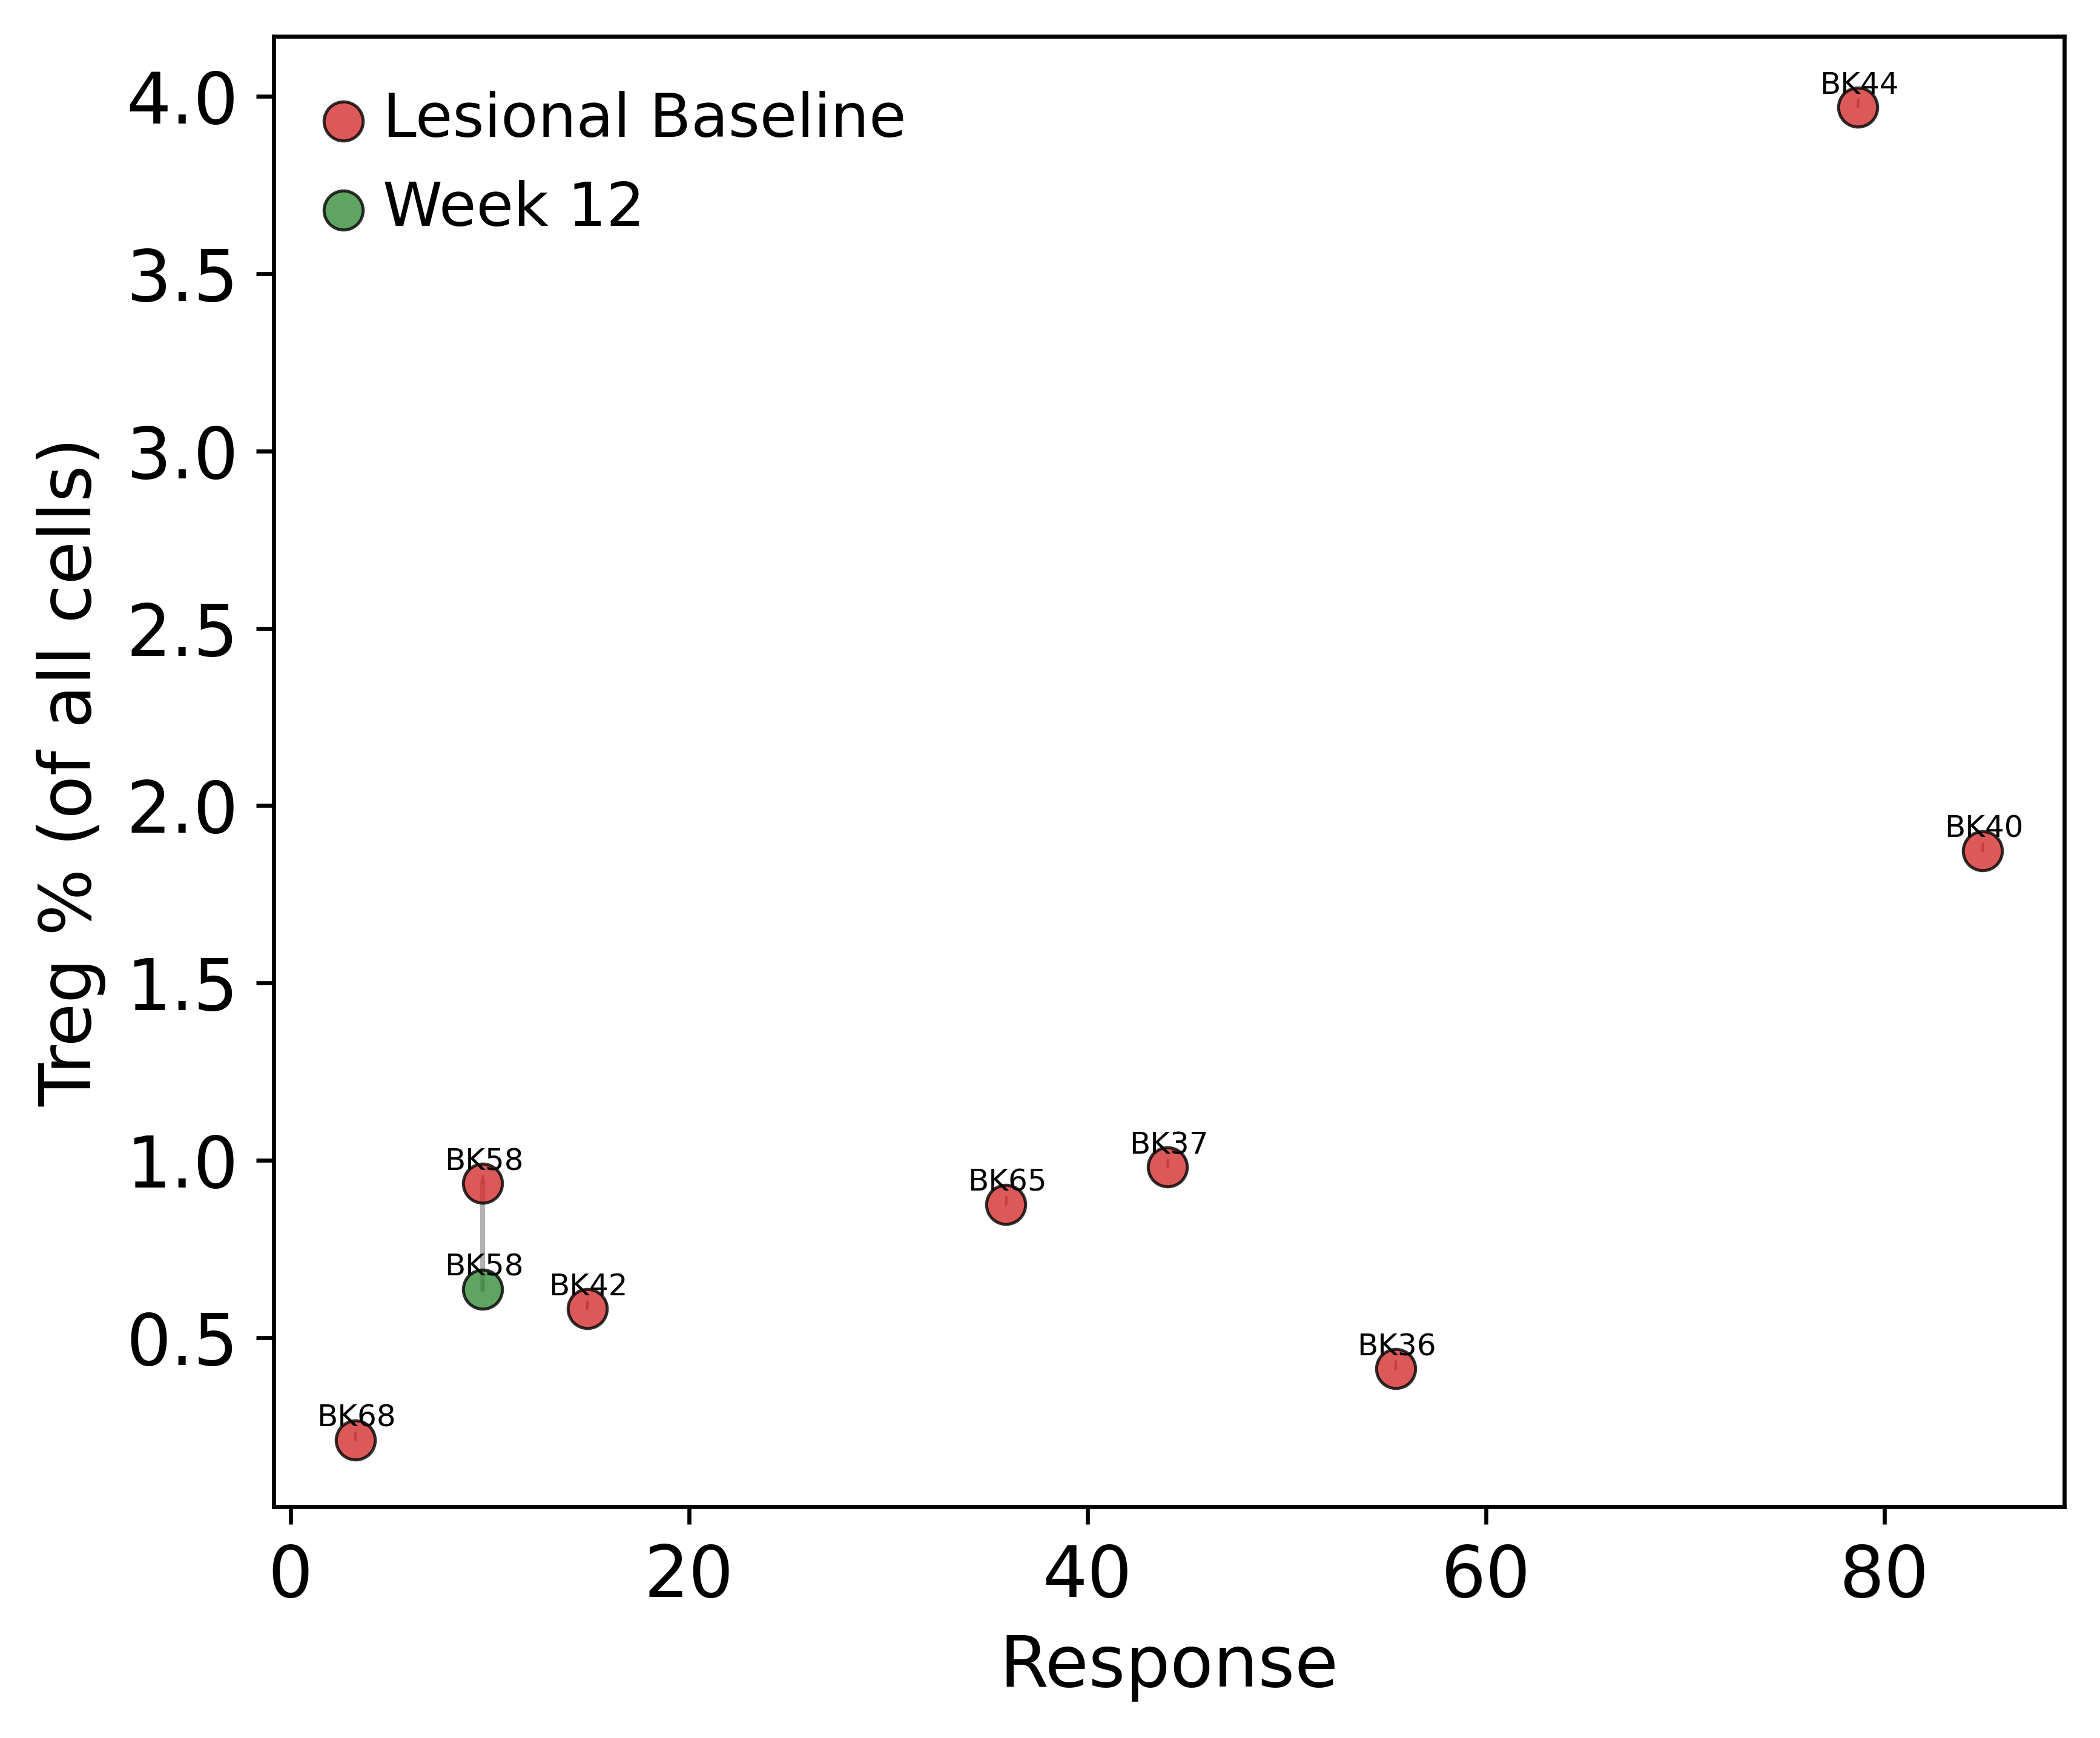

In [4]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata_new.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata_new.obs["Timepoint2"].astype(str).values,
    "response": adata_new.obs["response"].astype(float).values,
    "Cell_Type": adata_new.obs["lvl4_annotation"].astype(str).values
})
# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)
# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)
# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]
# ------------------------------------------------------------------
# Keep only the two timepoints of interest
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()
# ------------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------------
colors = {
    "Lesional Baseline": "#D32F2F",  # red
    "Week 12": "#388E3C",            # green
}
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
# plot points
for tp in timepoints:
    m = df_T["Timepoint2"] == tp
    ax.scatter(
        df_T.loc[m, "response"],
        df_T.loc[m, "Percent"],
        c=colors[tp],
        s=60,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.8,
        label=tp,
        zorder=3,
    )
# ------------------------------------------------------------------
# Add patient ID labels to each point
# ------------------------------------------------------------------
from adjustText import adjust_text

texts = []
for _, row in df_T.iterrows():
    texts.append(
        ax.text(
            row["response"],
            row["Percent"],
            row["PatientID"],
            fontsize=6,
            ha="center",
            va="bottom",
            zorder=4,
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5), ax=ax)
# ------------------------------------------------------------------
# Optional: connect same PatientID across timepoints
# ------------------------------------------------------------------
for pid, g in df_T.groupby("PatientID"):
    if g.shape[0] == 2:
        g = g.sort_values("Timepoint2")
        ax.plot(
            g["response"],
            g["Percent"],
            color="gray",
            lw=1,
            alpha=0.6,
            zorder=2,
        )
# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------
ax.set_xlabel("Response", fontsize=14)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)
ax.legend(frameon=False, fontsize=12)
ax.grid(False)
plt.tight_layout()
# plt.savefig(
#     "figures/Treg_percent_vs_response_scatter.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )
plt.show()

# all data

In [5]:
adata_reference_path= '/nfs/team298/ls34/adult_skin/final_adatas/adata_combined_new.h5ad.final.filtered'
adata_5k=sc.read_h5ad(adata_reference_path)

adata_5k=adata_5k[adata_5k.obs["tech"]=="xenium"]

def remove_markers(LIST):
    try: 
        LIST = {key: [gene for gene in genes if gene in adata_5k.var_names] 
                           for key, genes in LIST.items()}
    except: 
        LIST =[gene for gene in LIST if gene in adata_5k.var_names]
    return LIST
adata_5k=adata_5k[adata_5k.obs["Sanger patient ID"]!="BK21"] # CAME OFF MTX TO DUPI
adata_5k=adata_5k[adata_5k.obs["Responder"]!="psoriasis"].copy() # CAME OFF MTX TO DUPI
KEEP = ["Lesional Baseline", "Week 12" ]
adata_5k = adata_5k[adata_5k.obs["Timepoint2"].isin(KEEP)]


RENAME = {"MigDC (cDC2)": "MigDC",
         "Treg_LRRC32+": "Treg"
         }
adata_5k.obs["lvl4_annotation"]=adata_5k.obs["lvl5_annotation"].map(RENAME).fillna(adata_5k.obs["lvl5_annotation"])

adata_5k.obs["Sanger patient ID"].value_counts()
adata_5k.obs["drug"]=adata_5k.obs["Drug"]
adata = ad.concat([adata_5k, adata_new],
                     label="newdata",
                     keys=["old", "new"],
                     join='outer',
                    )
adata.obs["response"].value_counts()       


/tmp/ipykernel_581881/2725780044.py:22: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata_5k.obs["lvl4_annotation"]=adata_5k.obs["lvl5_annotation"].map(RENAME).fillna(adata_5k.obs["lvl5_annotation"])


response
 100.0    48561
 55.47    38094
 81.5     35680
-4.65     35588
 79.14    32822
 6.43     31216
 78.68    30151
 84.94    29527
 9.64     27201
 93.39    25637
 3.25     24602
 94.44    24219
 59.92    21329
 35.92    19762
 14.89    19273
 82.1     17183
 44.03    14787
Name: count, dtype: int64

In [6]:
# adata_5k.obs.sample_id.value_counts()

In [7]:
# adata_5k.obs.Site_status.value_counts()

In [8]:
counts_per_sample = adata.obs["info_id6"].value_counts()
valid_ids = counts_per_sample[counts_per_sample >= 5000].index
adata = adata[adata.obs["info_id6"].isin(valid_ids)].copy()

In [9]:
# [x for x in adata.obs.sample_id.unique() if "BK22" in x]

In [10]:
adata_5k[adata_5k.obs["Sanger patient ID"]=="BK22"].obs.Timepoint.value_counts()

Timepoint
Lesional Baseline    21567
Week 12               9649
Name: count, dtype: int64

# 6m EASI

In [11]:
# 6m response
easi_response = {
    "BK21": "7.69",
    "BK22": "6.43",
    "BK58": "9.64",
    "BK59": "91.33",
    "BK65": "35.92",
    "BK68": "3.25",
    "BK18": "79.14",
    "BK19": "59.65",
    "BK20": "100.00",
    "BK23": "94.98",
    "BK24": "97.40",
    "BK25": "93.39",
    "BK26": "92.75",
    "BK30": "89.53",
    "BK38": "72.56",
    "BK39": "100.00",
    "BK41": "73.43",
    "BK60": "100.00",
    "BK61": "82.44",
    "BK62": "92.87",
    "BK63": "65.06",
    "BK64": "100.00",
    "BK67": "78.26",
    "BK69": "61.08",
    "BK71": "-6.93",
    "BK37": "44.03",
    "BK42": "14.89",
    "BK78": "-13.33",
    "BK36": "71.09",
    "BK40": "84.94",
    "BK44": "78.68",
    "BK66": "100.00",
    "BK76": "100.00",
    "BK28": "27.82",
    "BK29": "4.85",
    "BK47": "10.89",
    "BK27": "59.92",
    "BK31": "95.16",
    "BK45": "82.99",
    "BK48": "69.75",
    "BK75": "85.84",
    "BK77": "87.04",
    "BK79": "95.24",
}



adata.obs["response"]=adata.obs["Sanger patient ID"].map(easi_response)

patient_to_response = adata.obs.drop_duplicates("Sanger patient ID").set_index("Sanger patient ID")["response"].to_dict()
patient_to_response

 


{'BK51': nan,
 'BK49': nan,
 'BK22': '6.43',
 'BK23': '94.98',
 'BK27': '59.92',
 'BK18': '79.14',
 'BK20': '100.00',
 'BK39': '100.00',
 'BK25': '93.39',
 'BK30': '89.53',
 'BK24': '97.40',
 'BK44': '78.68',
 'BK36': '71.09',
 'BK37': '44.03',
 'BK58': '9.64',
 'BK68': '3.25',
 'BK65': '35.92',
 'BK42': '14.89',
 'BK40': '84.94'}

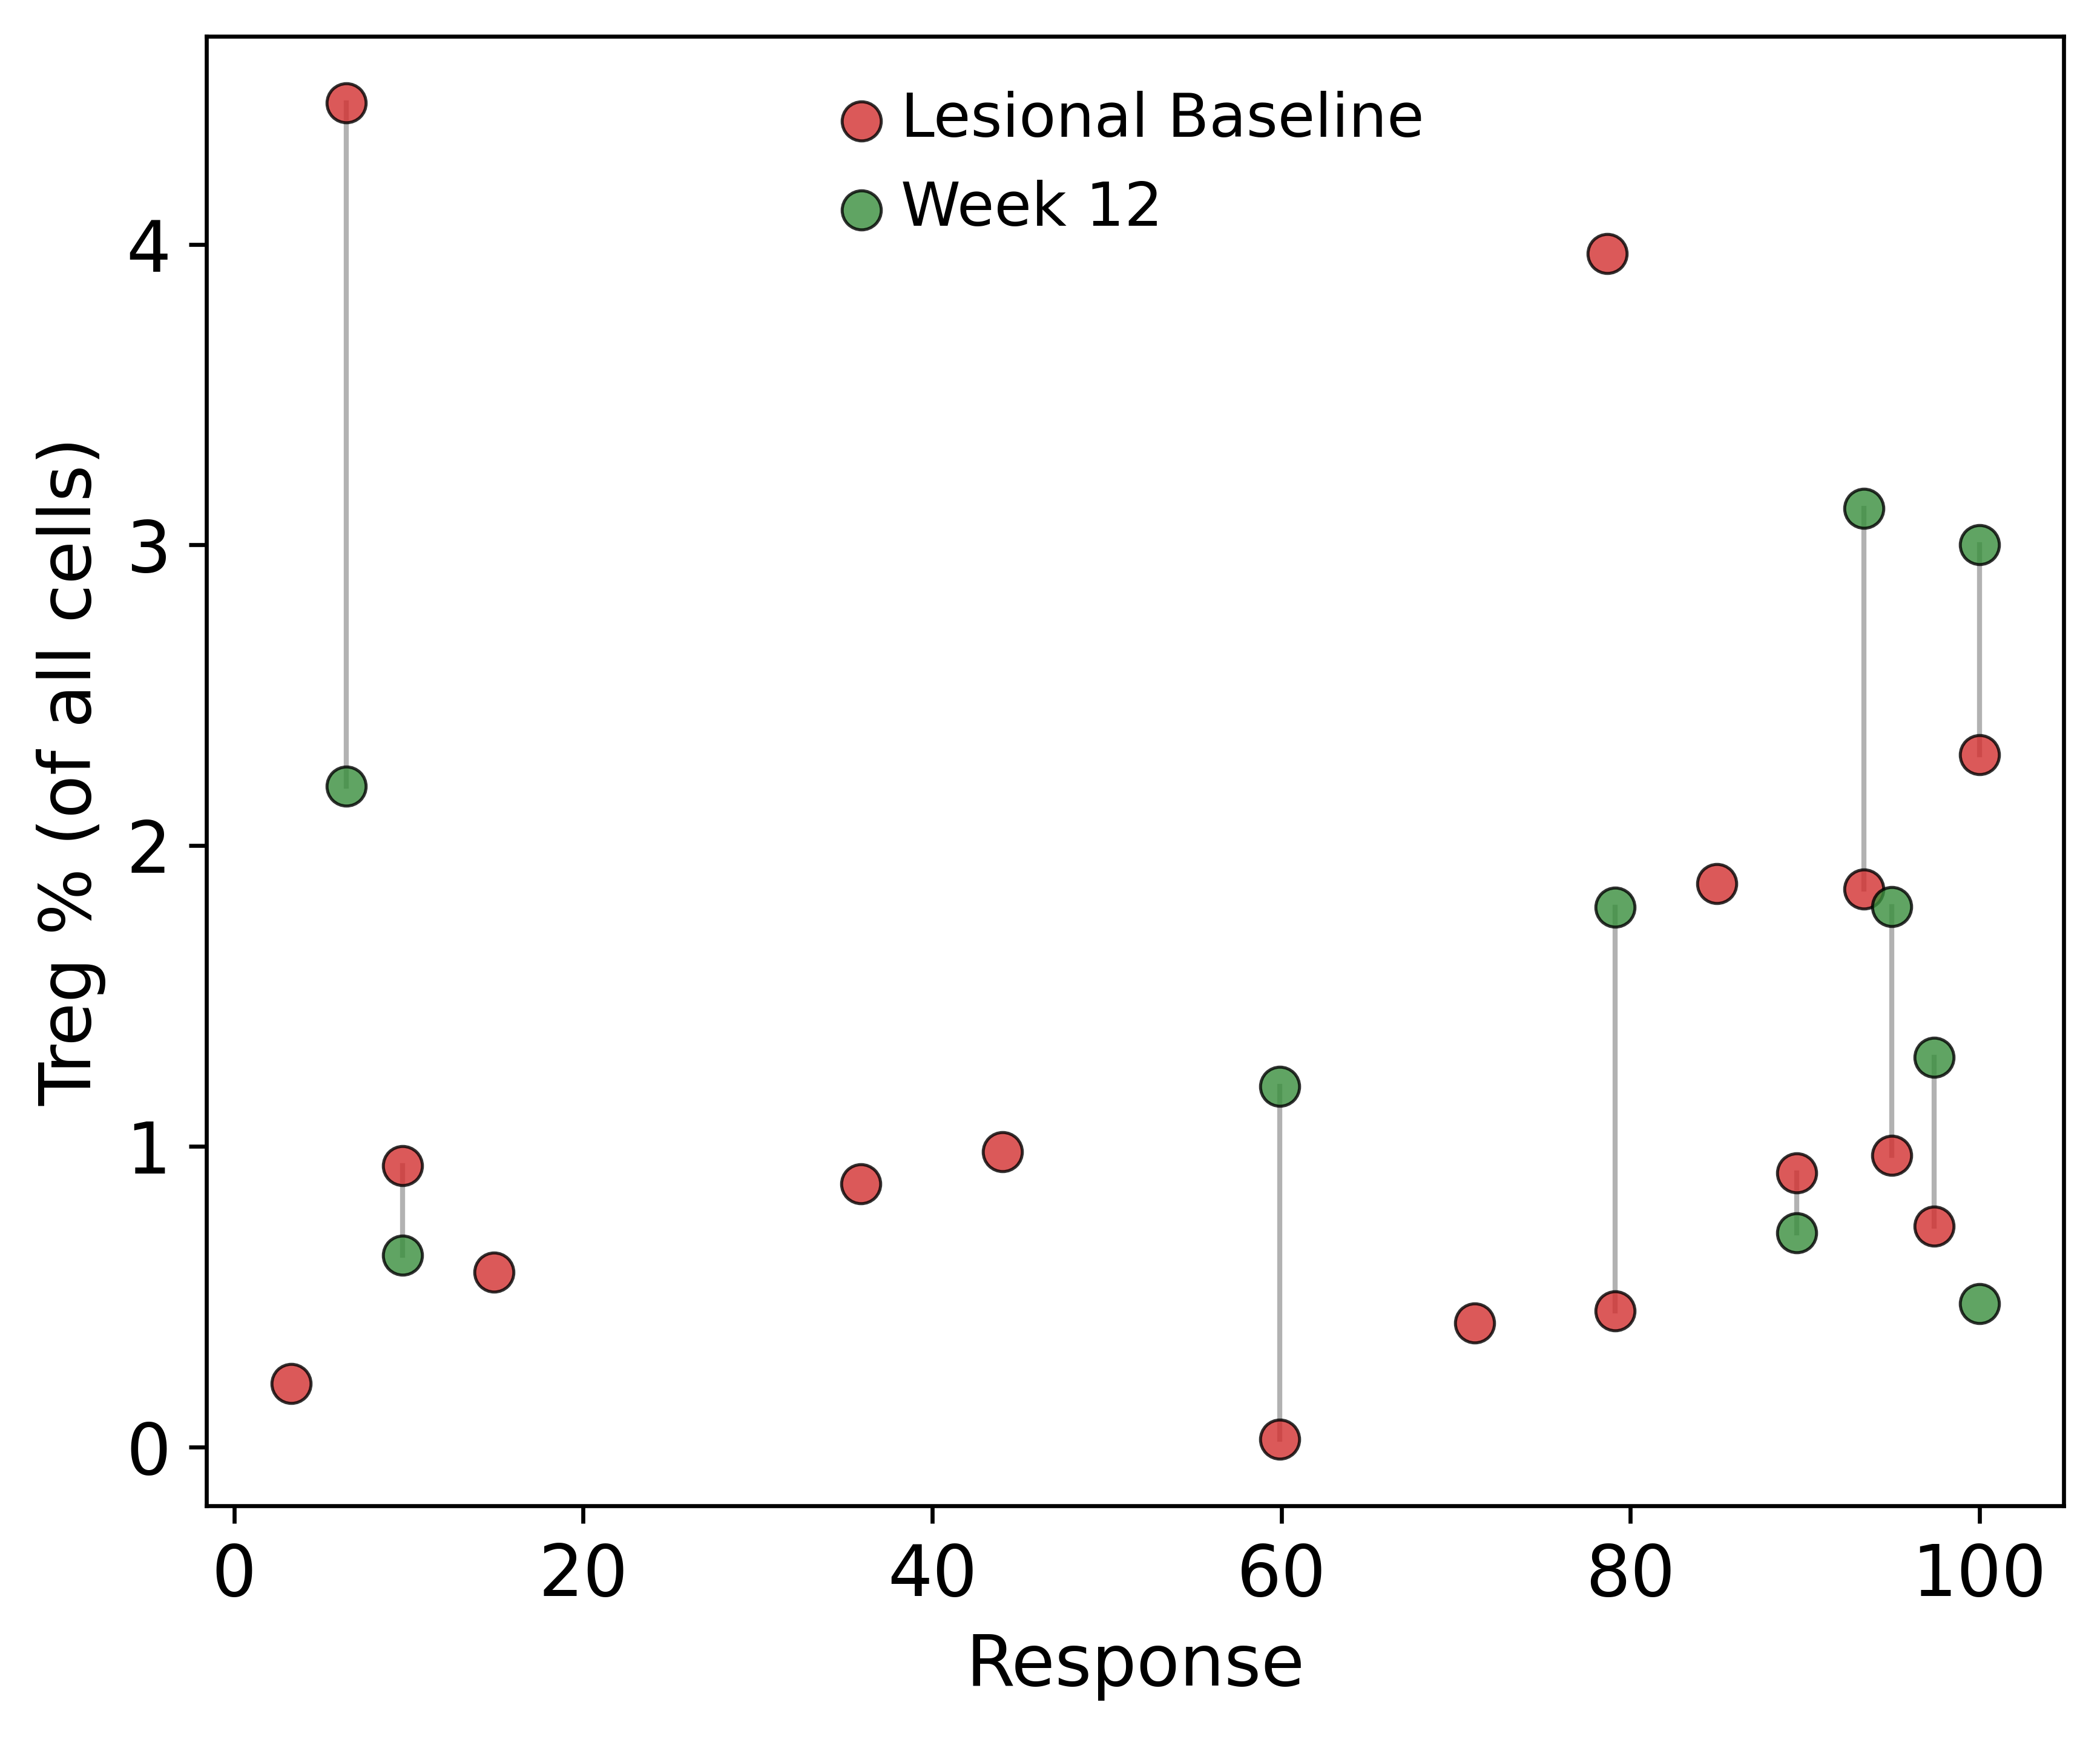

In [12]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})
# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)
# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)
# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]
# ------------------------------------------------------------------
# Keep only the two timepoints of interest
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()
# ------------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------------
colors = {
    "Lesional Baseline": "#D32F2F",  # red
    "Week 12": "#388E3C",            # green
}
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)
# plot points
for tp in timepoints:
    m = df_T["Timepoint2"] == tp
    ax.scatter(
        df_T.loc[m, "response"],
        df_T.loc[m, "Percent"],
        c=colors[tp],
        s=60,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.8,
        label=tp,
        zorder=3,
    )
# ------------------------------------------------------------------
# Add patient ID labels to each point
# ------------------------------------------------------------------
# from adjustText import adjust_text

# texts = []
# for _, row in df_T.iterrows():
#     texts.append(
#         ax.text(
#             row["response"],
#             row["Percent"],
#             row["PatientID"],
#             fontsize=6,
#             ha="center",
#             va="bottom",
#             zorder=4,
#         )
#     )
# adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5), ax=ax)
# ------------------------------------------------------------------
# Optional: connect same PatientID across timepoints
# ------------------------------------------------------------------
for pid, g in df_T.groupby("PatientID"):
    if g.shape[0] == 2:
        g = g.sort_values("Timepoint2")
        ax.plot(
            g["response"],
            g["Percent"],
            color="gray",
            lw=1,
            alpha=0.6,
            zorder=2,
        )
# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------
ax.set_xlabel("Response", fontsize=14)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)
ax.legend(frameon=False, fontsize=12)
ax.grid(False)
plt.tight_layout()
plt.savefig(
    "figures/Treg_percent_vs_response_scatter.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

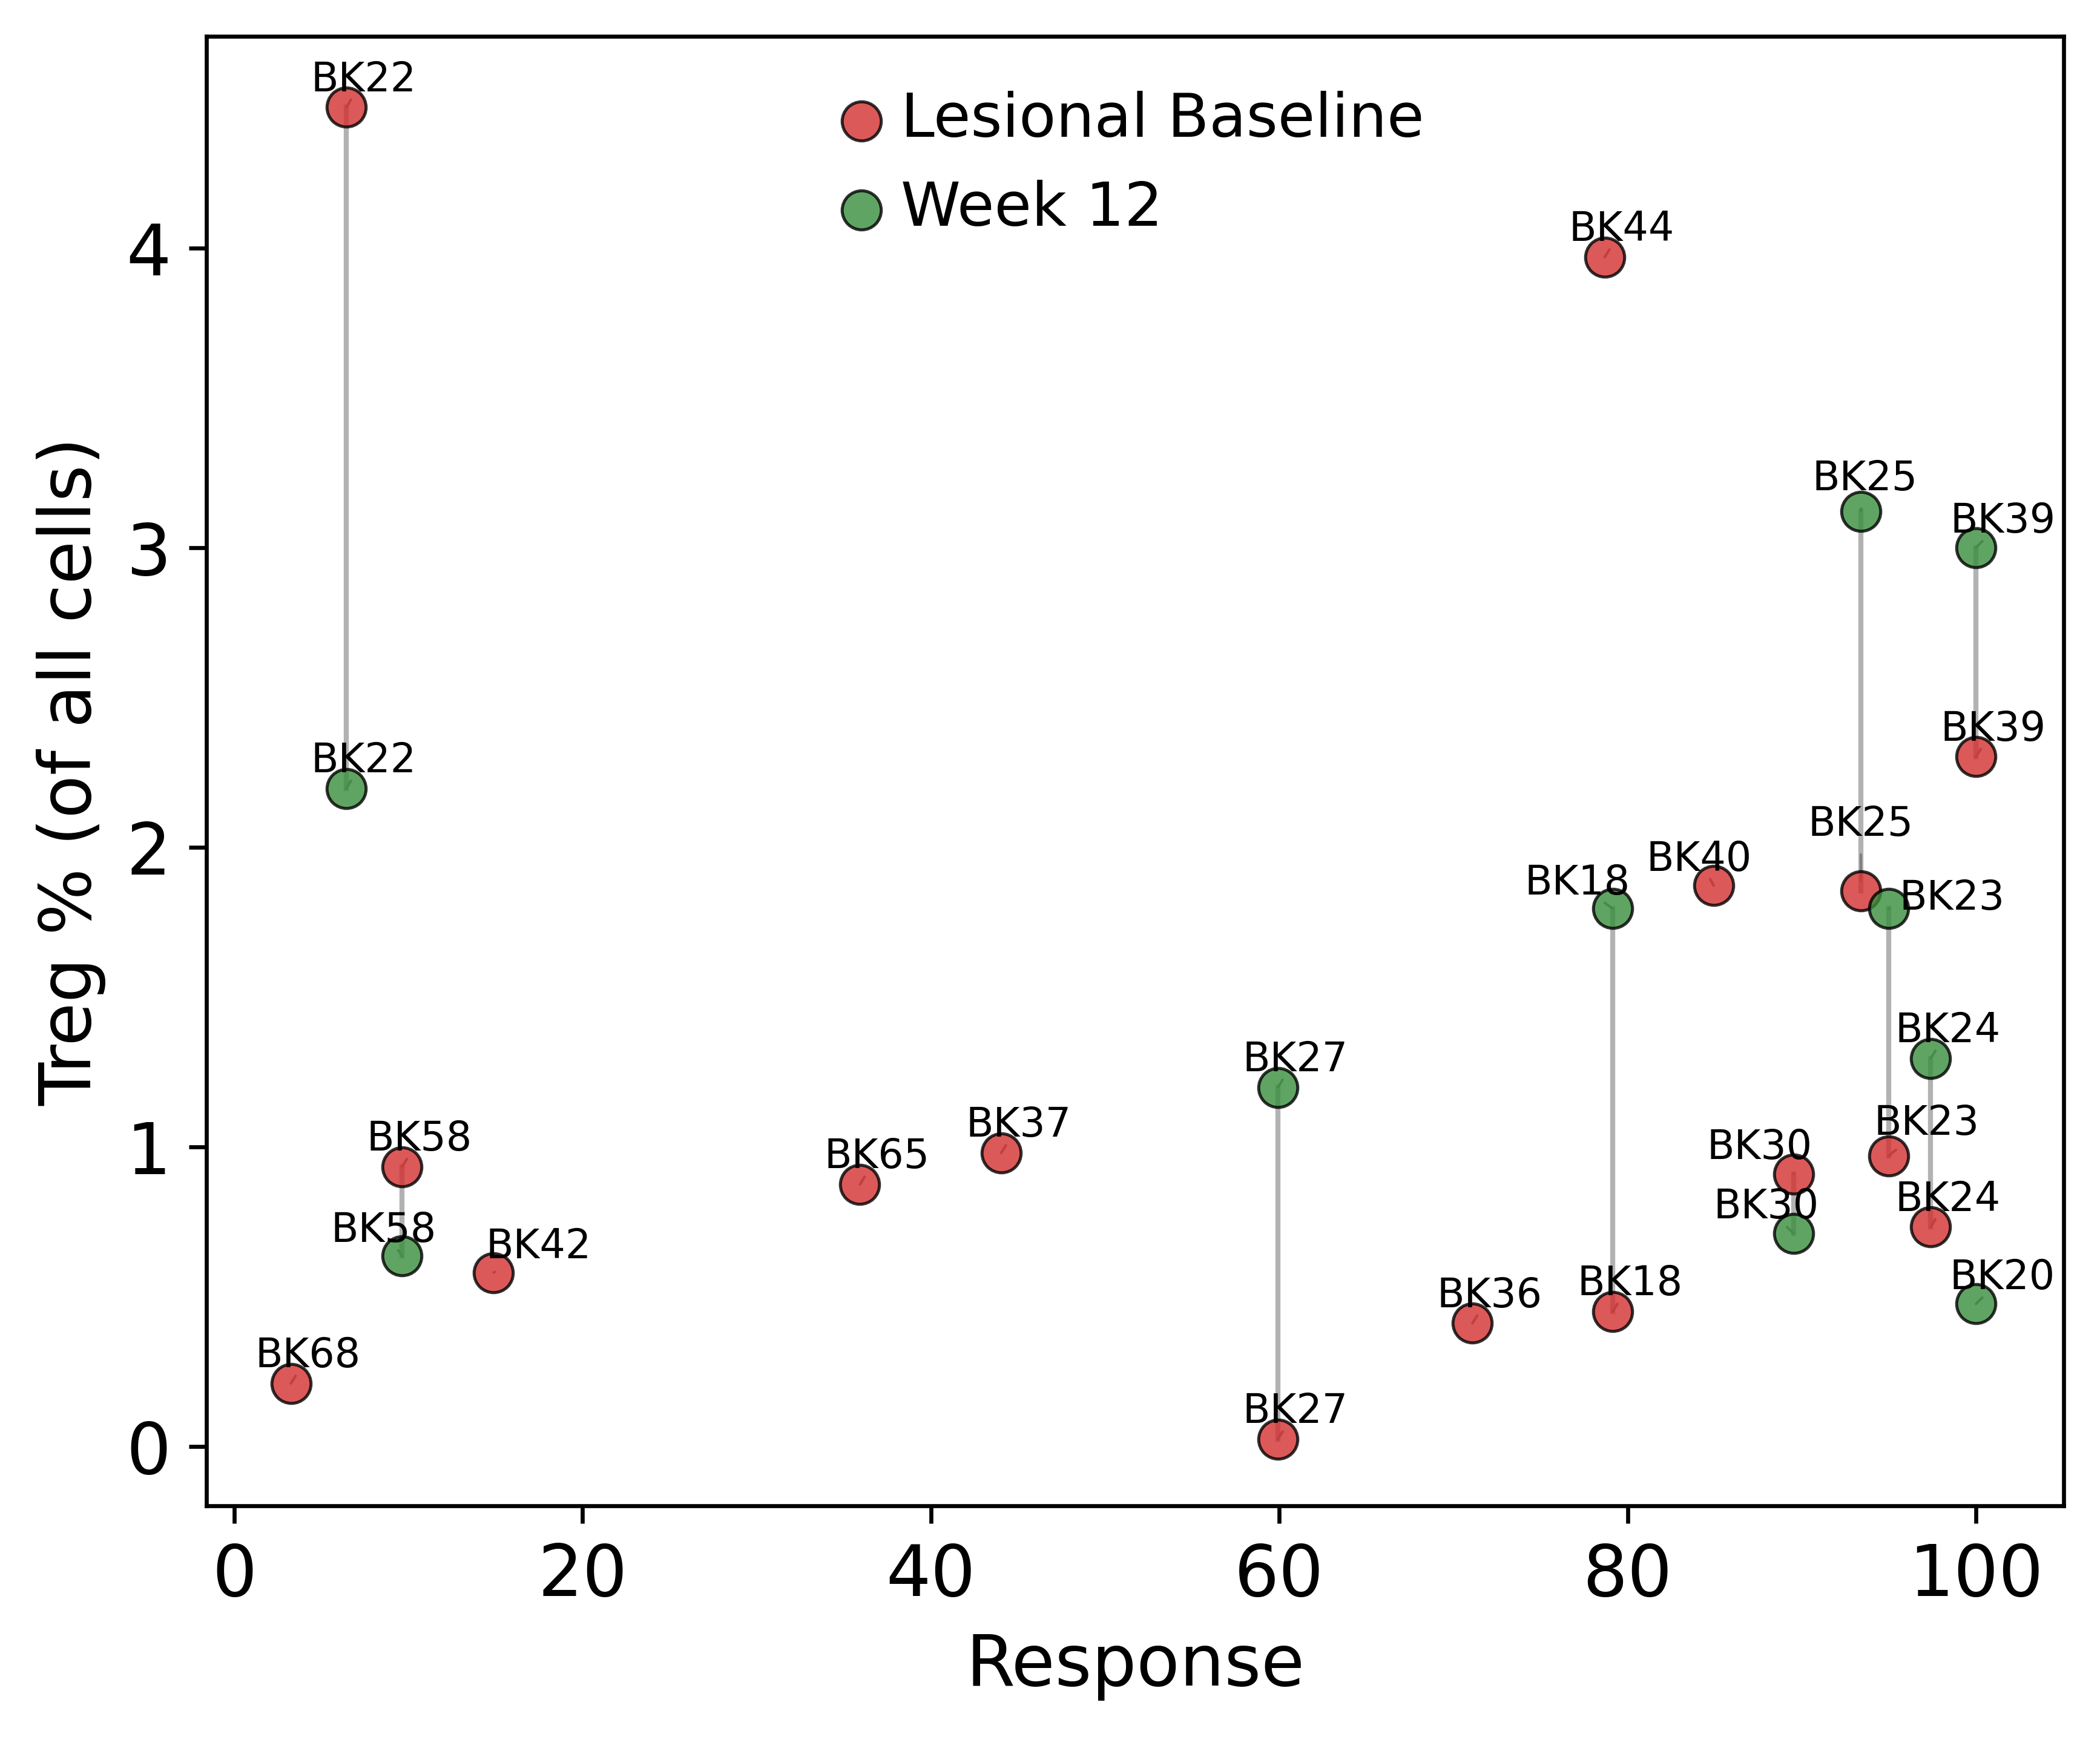

In [13]:

# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": (
        adata.obs["Sanger patient ID"].astype(str)
    ).values,   # composite label (ID + drug) for plot annotations
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values,
    "drug": adata.obs["drug"].astype(str).values,   # keep drug separate
})

# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response", "drug"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response", "drug"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response", "drug"])
    .fillna({"Treg": 0})
)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep only the two timepoints of interest
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

# ------------------------------------------------------------------
# Figure out which drug(s) are represented
# ------------------------------------------------------------------
drugs_present = sorted(df_T["drug"].dropna().unique())
drug_label = ", ".join(drugs_present) if drugs_present else "unknown"

# ------------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------------
colors = {
    "Lesional Baseline": "#D32F2F",  # red
    "Week 12": "#388E3C",            # green
}
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

for tp in timepoints:
    m = df_T["Timepoint2"] == tp
    ax.scatter(
        df_T.loc[m, "response"],
        df_T.loc[m, "Percent"],
        c=colors[tp],
        s=60,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.8,
        label=tp,
        zorder=3,
    )

# ------------------------------------------------------------------
# Patient ID labels (includes drug in the string)
# ------------------------------------------------------------------
texts = []
for _, row in df_T.iterrows():
    texts.append(
        ax.text(
            row["response"],
            row["Percent"],
            row["PatientID"],
            fontsize=8,
            ha="center",
            va="bottom",
            zorder=4,
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5), ax=ax)

# ------------------------------------------------------------------
# Connect same PatientID across timepoints
# ------------------------------------------------------------------
for pid, g in df_T.groupby("PatientID"):
    if g.shape[0] == 2:
        g = g.sort_values("Timepoint2")
        ax.plot(
            g["response"],
            g["Percent"],
            color="gray",
            lw=1,
            alpha=0.6,
            zorder=2,
        )

# ------------------------------------------------------------------
# Formatting + drug annotation
# ------------------------------------------------------------------
ax.set_xlabel("Response", fontsize=14)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)
ax.legend(frameon=False, fontsize=12)
ax.grid(False)

# # Drug text in upper-left corner of axes
# ax.text(
#     0.02, 0.98,
#     f"Drug: {drug_label}",
#     transform=ax.transAxes,
#     ha="left", va="top",
#     fontsize=11, fontweight="bold",
#     bbox=dict(facecolor="white", edgecolor="lightgray", alpha=0.9),
# )

plt.tight_layout()
plt.savefig(
    "figures/Treg_percent_vs_response_scatter_withID.pdf",
    dpi=300,
    bbox_inches="tight",
)
plt.show()

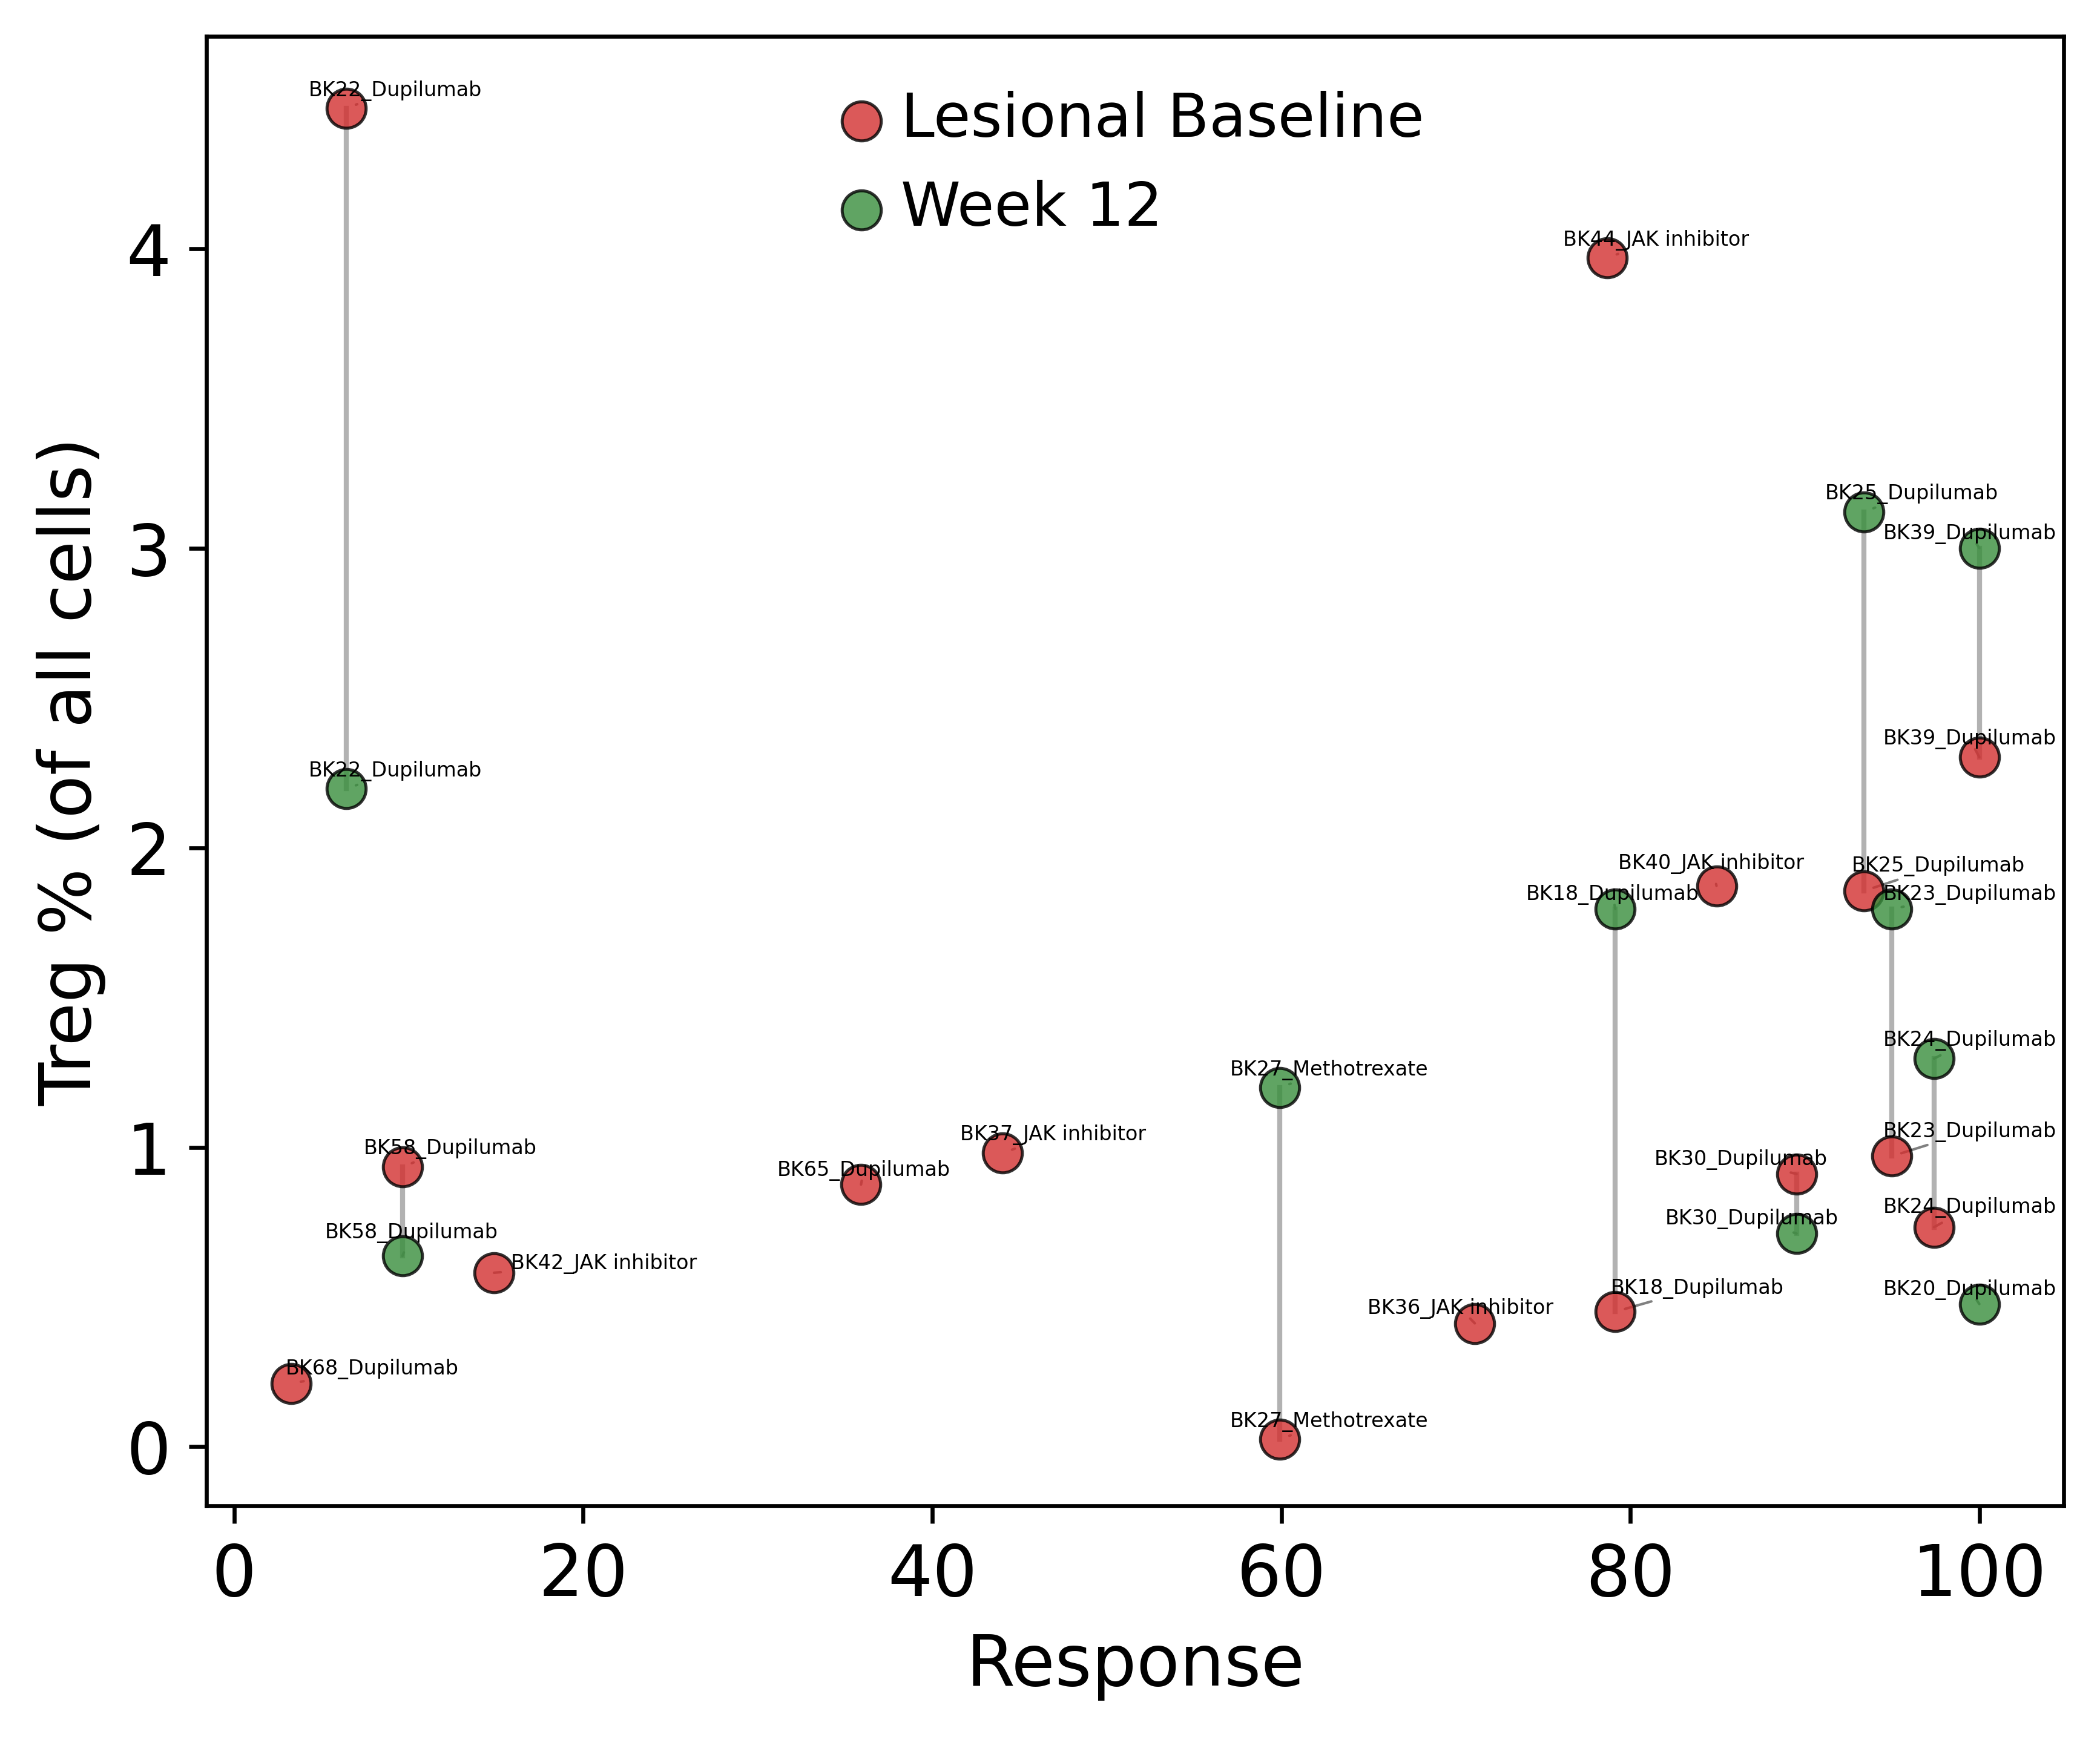

In [14]:

# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": (
        adata.obs["Sanger patient ID"].astype(str)
        + "_"
        + adata.obs["drug"].astype(str)
    ).values,   # composite label (ID + drug) for plot annotations
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values,
    "drug": adata.obs["drug"].astype(str).values,   # keep drug separate
})

# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response", "drug"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response", "drug"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response", "drug"])
    .fillna({"Treg": 0})
)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep only the two timepoints of interest
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

# ------------------------------------------------------------------
# Figure out which drug(s) are represented
# ------------------------------------------------------------------
drugs_present = sorted(df_T["drug"].dropna().unique())
drug_label = ", ".join(drugs_present) if drugs_present else "unknown"

# ------------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------------
colors = {
    "Lesional Baseline": "#D32F2F",  # red
    "Week 12": "#388E3C",            # green
}
fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

for tp in timepoints:
    m = df_T["Timepoint2"] == tp
    ax.scatter(
        df_T.loc[m, "response"],
        df_T.loc[m, "Percent"],
        c=colors[tp],
        s=60,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.8,
        label=tp,
        zorder=3,
    )

# ------------------------------------------------------------------
# Patient ID labels (includes drug in the string)
# ------------------------------------------------------------------
texts = []
for _, row in df_T.iterrows():
    texts.append(
        ax.text(
            row["response"],
            row["Percent"],
            row["PatientID"],
            fontsize=4,
            ha="center",
            va="bottom",
            zorder=4,
        )
    )
adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5), ax=ax)

# ------------------------------------------------------------------
# Connect same PatientID across timepoints
# ------------------------------------------------------------------
for pid, g in df_T.groupby("PatientID"):
    if g.shape[0] == 2:
        g = g.sort_values("Timepoint2")
        ax.plot(
            g["response"],
            g["Percent"],
            color="gray",
            lw=1,
            alpha=0.6,
            zorder=2,
        )

# ------------------------------------------------------------------
# Formatting + drug annotation
# ------------------------------------------------------------------
ax.set_xlabel("Response", fontsize=14)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)
ax.legend(frameon=False, fontsize=12)
ax.grid(False)

# # Drug text in upper-left corner of axes
# ax.text(
#     0.02, 0.98,
#     f"Drug: {drug_label}",
#     transform=ax.transAxes,
#     ha="left", va="top",
#     fontsize=11, fontweight="bold",
#     bbox=dict(facecolor="white", edgecolor="lightgray", alpha=0.9),
# )

plt.tight_layout()
# plt.savefig(
#     "figures/Treg_percent_vs_response_scatter.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )
plt.show()

In [15]:
adata.obs.drug.value_counts()  

drug
Dupilumab        346017
JAK inhibitor    131832
Methotrexate      21329
Name: count, dtype: int64

Mann–Whitney U test p-value = 0.055556


/tmp/ipykernel_581881/332097973.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_581881/332097973.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


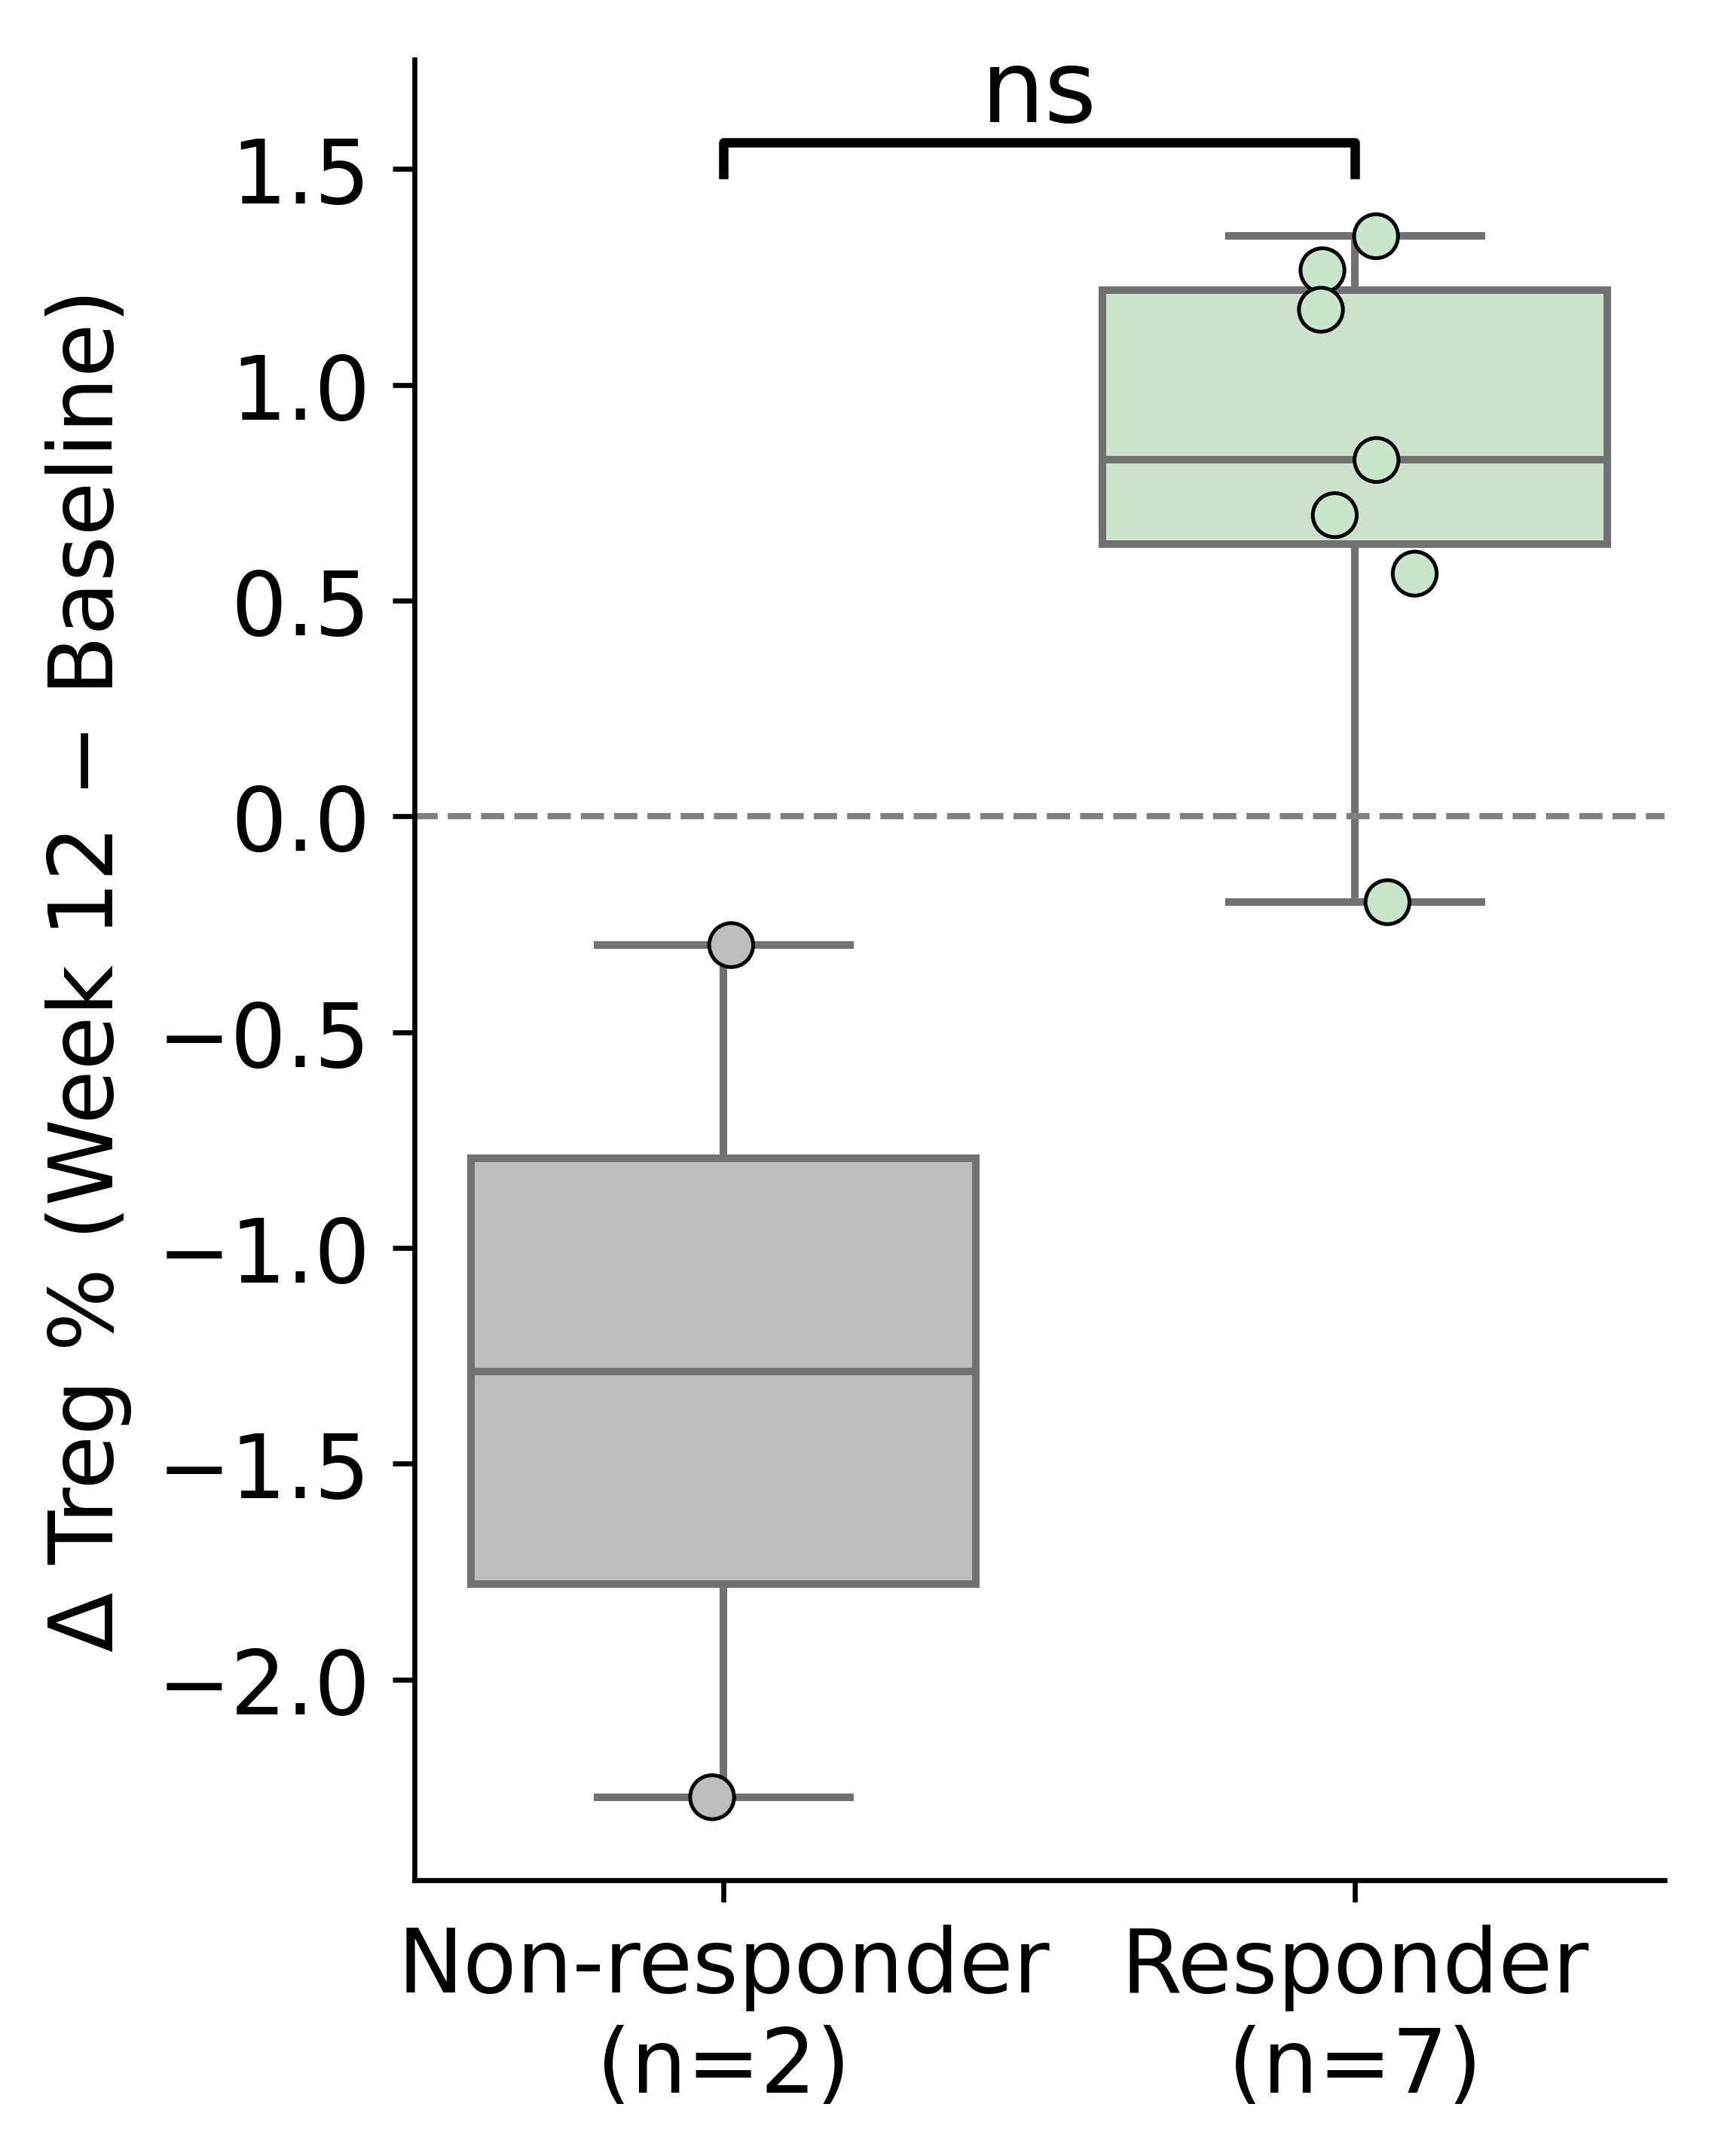

In [16]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge + compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep paired samples only
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to wide format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta (paired change)
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Binary response classification
# ------------------------------------------------------------------
df_wide["Response_group"] = np.where(
    df_wide["response"] > 50,
    "Responder",
    "Non-responder"
)

order = ["Non-responder", "Responder"]

# ------------------------------------------------------------------
# Statistical test
# ------------------------------------------------------------------
responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")
print(f"Mann–Whitney U test p-value = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(4, 5), dpi=300)

palette = {
    "Non-responder": "#BDBDBD",
    "Responder": "#C8E6C9"
}

ax = sns.boxplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    showfliers=False,
    linewidth=1.2
)

sns.stripplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    size=7,
    jitter=True
)

# Zero reference line
ax.axhline(0, ls="--", color="gray", lw=1)

# ------------------------------------------------------------------
# Significance bar + star
# ------------------------------------------------------------------
ymax = df_wide["delta"].max()
ymin = df_wide["delta"].min()
yrange = ymax - ymin

bar_height = ymax + 0.04 * yrange
tick_height = 0.02 * yrange
star_offset = 0.02 * yrange

x1, x2 = 0, 1
ax.plot(
    [x1, x1, x2, x2],
    [bar_height, bar_height + tick_height,
     bar_height + tick_height, bar_height],
    lw=1.5, color="black"
)

if pval < 0.001:
    star = "***"
elif pval < 0.01:
    star = "**"
elif pval < 0.05:
    star = "*"
else:
    star = "ns"

ax.text(
    0.5,
    bar_height + star_offset,
    star,
    ha="center",
    va="bottom",
    fontsize=16
)

# ------------------------------------------------------------------
# X-tick labels with sample counts
# ------------------------------------------------------------------
counts = df_wide["Response_group"].value_counts()
new_labels = [f"{grp}\n(n={counts[grp]})" for grp in order]
ax.set_xticks([0, 1])
ax.set_xticklabels(new_labels)

# ------------------------------------------------------------------
# Aesthetics cleanup
# ------------------------------------------------------------------
ax.set_ylabel("Δ Treg % (Week 12 − Baseline)", fontsize=14)
ax.set_xlabel("")
ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("boxplot_treg_abundance.pdf", dpi=300, bbox_inches="tight")

plt.show()



/tmp/ipykernel_581881/203876658.py:104: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_581881/203876658.py:114: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


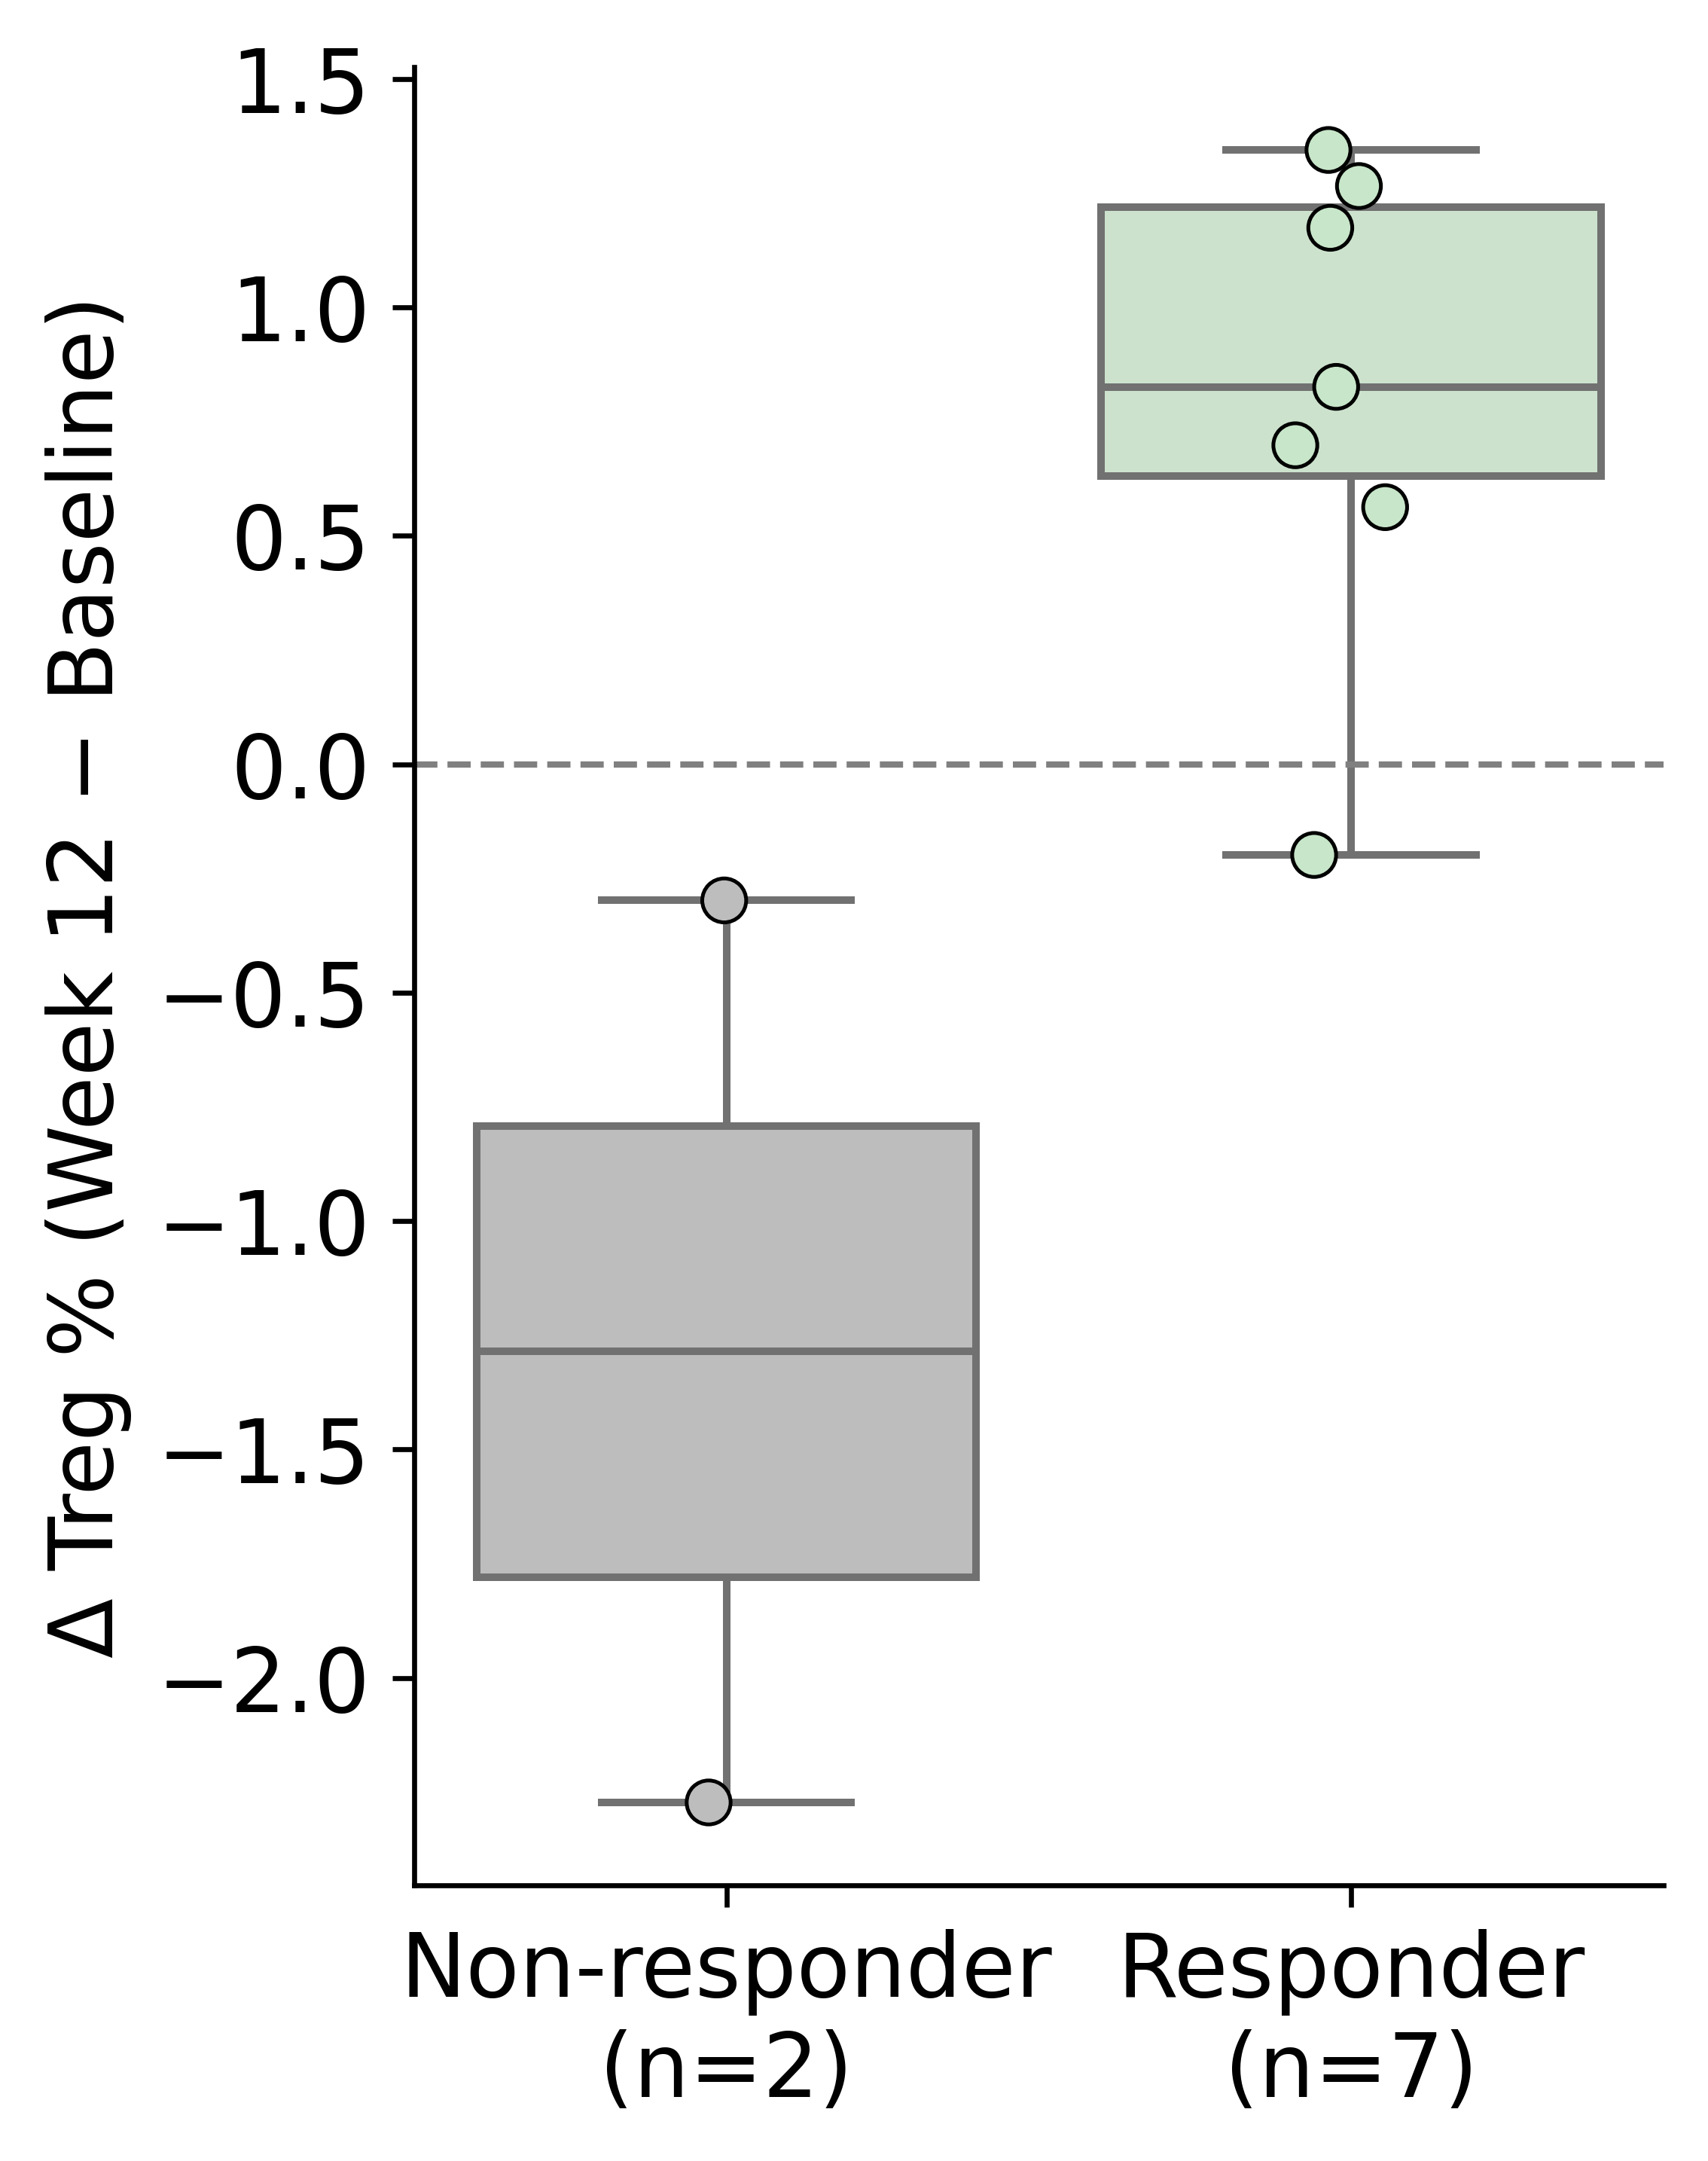

In [17]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge + compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep paired samples only
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to wide format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta (paired change)
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Binary response classification
# ------------------------------------------------------------------
df_wide["Response_group"] = np.where(
    df_wide["response"] > 50,
    "Responder",
    "Non-responder"
)

order = ["Non-responder", "Responder"]

# ------------------------------------------------------------------
# Statistical test
# ------------------------------------------------------------------
responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

# stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")
# print(f"Mann–Whitney U test p-value = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(4, 5), dpi=300)

palette = {
    "Non-responder": "#BDBDBD",
    "Responder": "#C8E6C9"
}

ax = sns.boxplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    showfliers=False,
    linewidth=1.2
)

sns.stripplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    size=7,
    jitter=True
)

# Zero reference line
ax.axhline(0, ls="--", color="gray", lw=1)

# ------------------------------------------------------------------
# Significance bar + star
# ------------------------------------------------------------------
# ymax = df_wide["delta"].max()
# ymin = df_wide["delta"].min()
# yrange = ymax - ymin

# bar_height = ymax + 0.04 * yrange
# tick_height = 0.02 * yrange
# star_offset = 0.02 * yrange

# x1, x2 = 0, 1
# ax.plot(
#     [x1, x1, x2, x2],
#     [bar_height, bar_height + tick_height,
#      bar_height + tick_height, bar_height],
#     lw=1.5, color="black"
# )

# if pval < 0.001:
#     star = "***"
# elif pval < 0.01:
#     star = "**"
# elif pval < 0.05:
#     star = "*"
# else:
#     star = "ns"

# ax.text(
#     0.5,
#     bar_height + star_offset,
#     star,
#     ha="center",
#     va="bottom",
#     fontsize=16
# )

# ------------------------------------------------------------------
# X-tick labels with sample counts
# ------------------------------------------------------------------
counts = df_wide["Response_group"].value_counts()
new_labels = [f"{grp}\n(n={counts[grp]})" for grp in order]
ax.set_xticks([0, 1])
ax.set_xticklabels(new_labels)

# ------------------------------------------------------------------
# Aesthetics cleanup
# ------------------------------------------------------------------
ax.set_ylabel("Δ Treg % (Week 12 − Baseline)", fontsize=14)
ax.set_xlabel("")
ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("boxplot_treg_change2.pdf", dpi=300, bbox_inches="tight")

plt.show()



Mann–Whitney U test p-value = 0.333333


/tmp/ipykernel_581881/3243388036.py:113: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(
/tmp/ipykernel_581881/3243388036.py:124: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  strip = sns.stripplot(


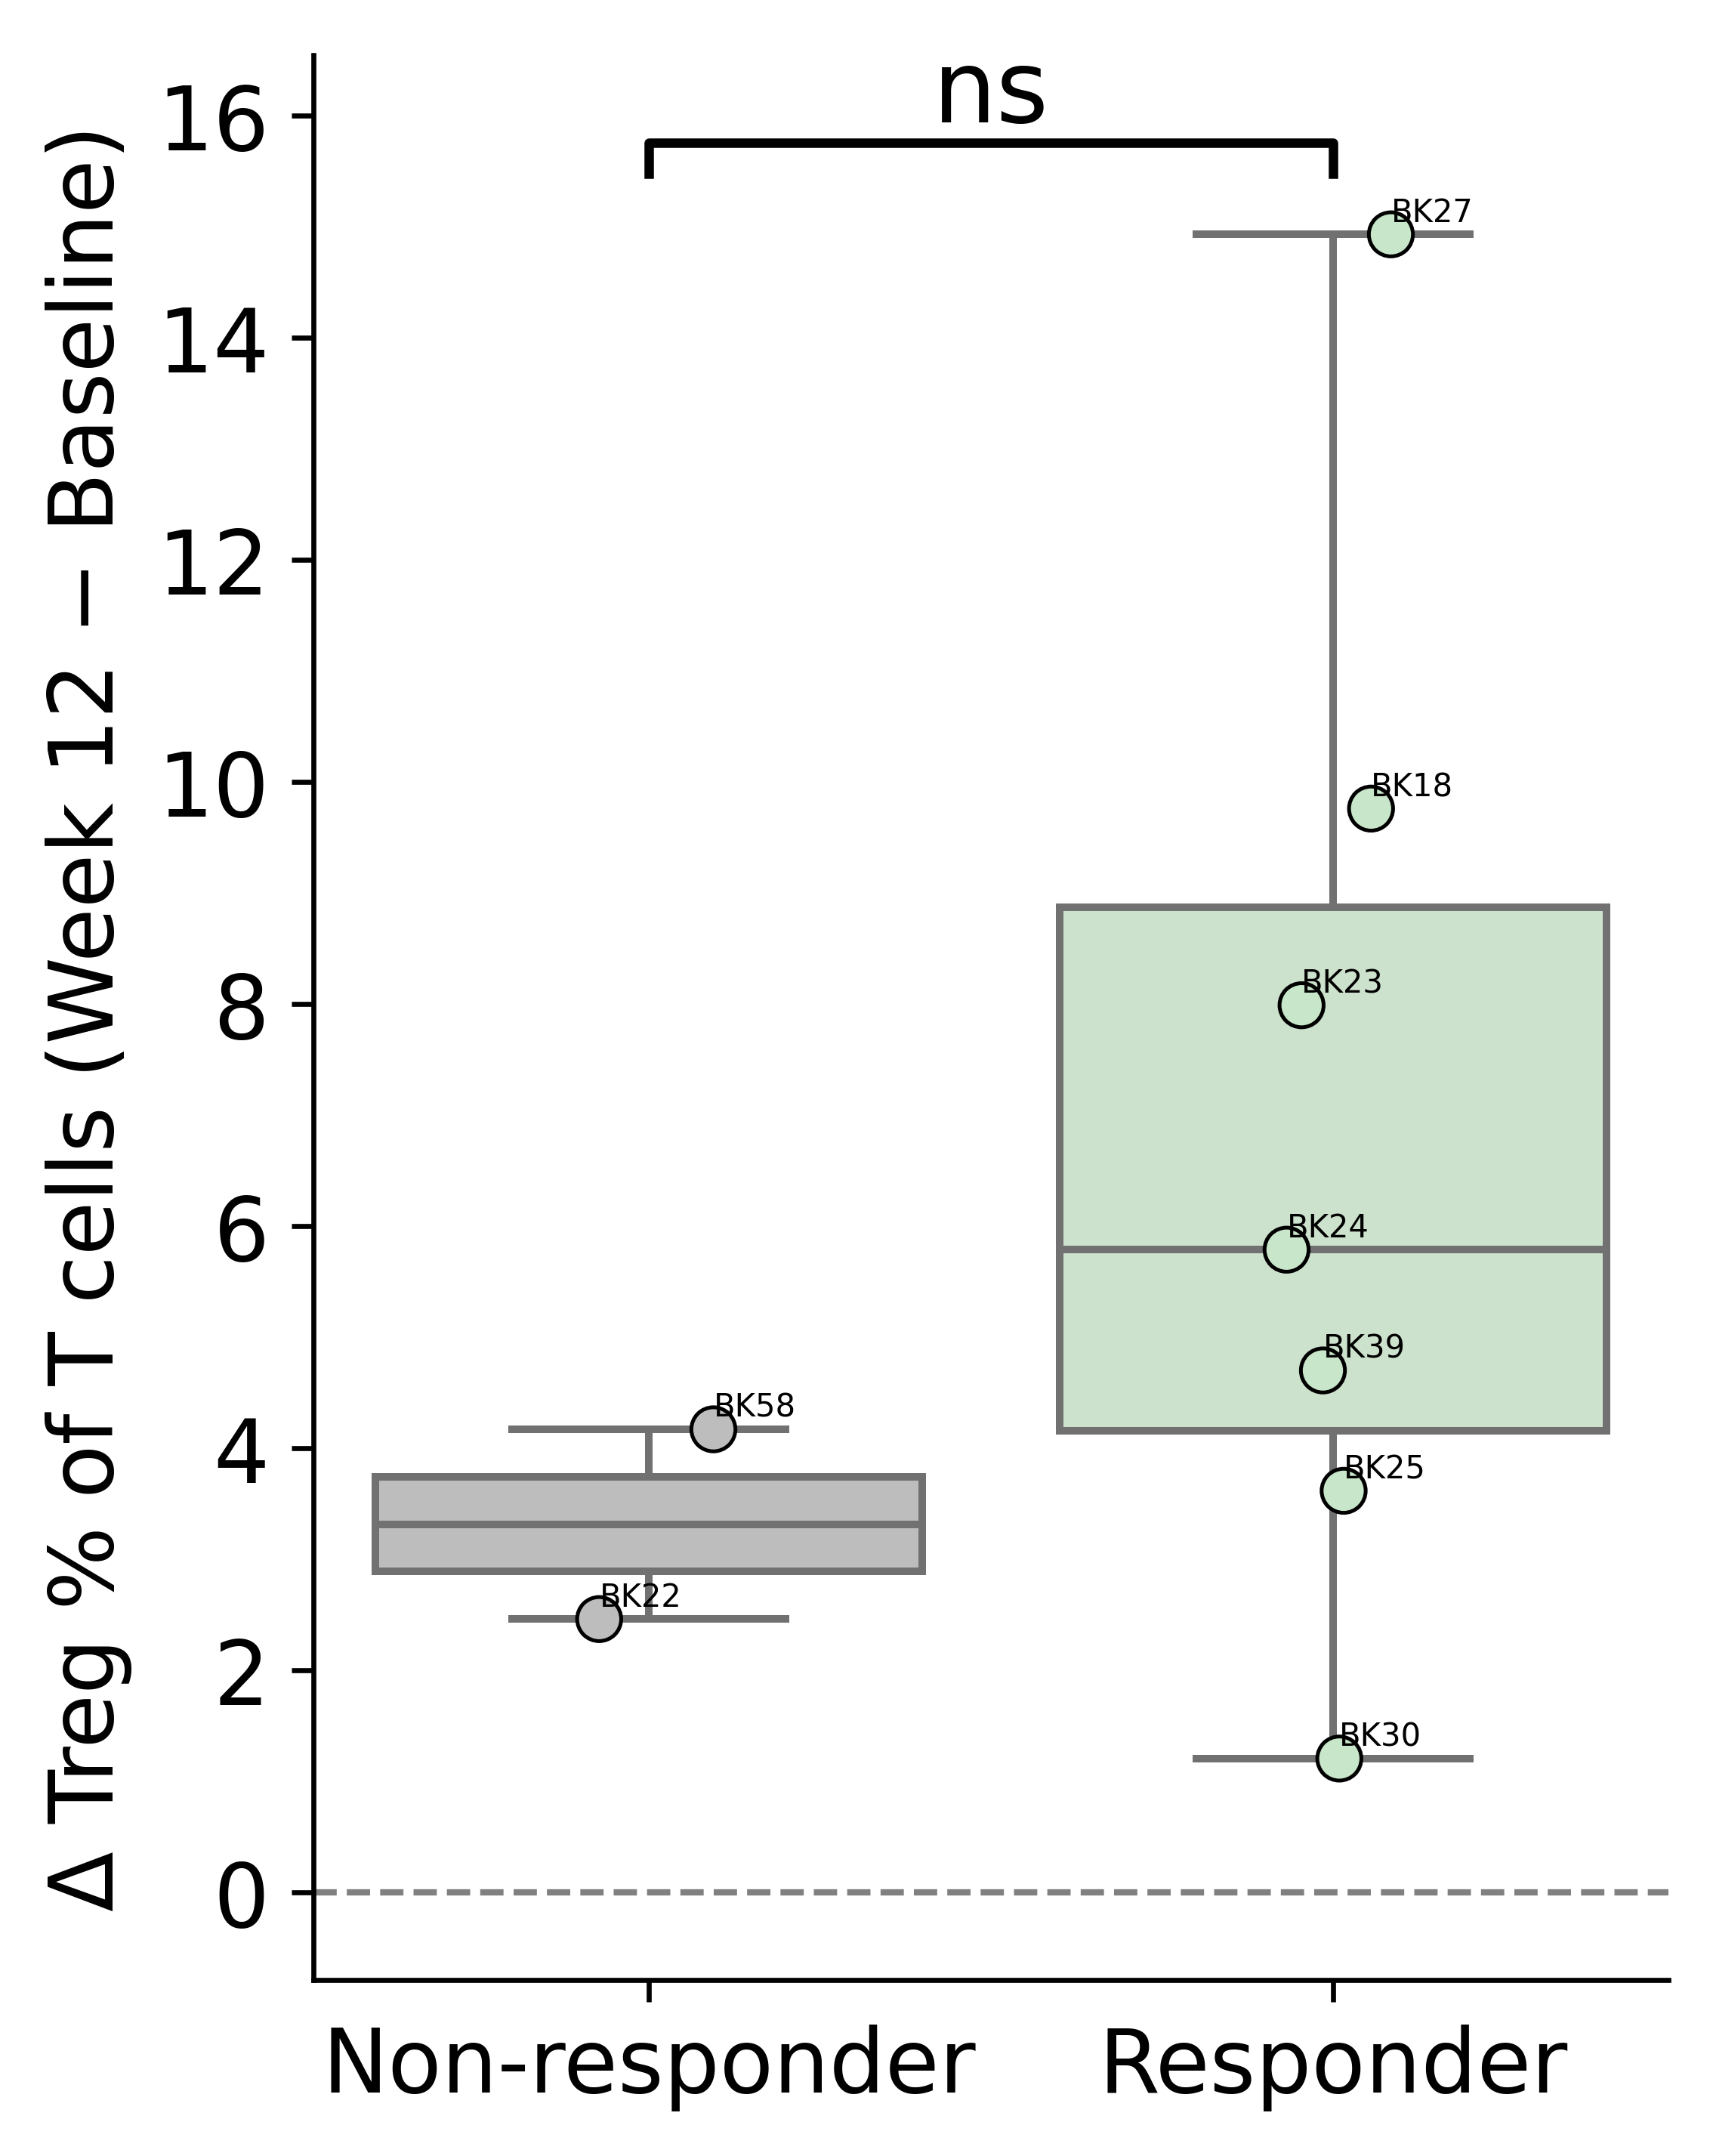

In [18]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Filter to T cells only (denominator)
# ------------------------------------------------------------------
t_cell_mask = (
    df_all["Cell_Type"].str.startswith("T")
    & (df_all["Cell_Type"] != "TransitionalDC")
)
df_tcells = df_all[t_cell_mask].copy()

# ------------------------------------------------------------------
# Total T cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_tcells
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_Tcells")
)

# ------------------------------------------------------------------
# Treg counts (numerator)
# ------------------------------------------------------------------
trg = (
    df_tcells[df_tcells["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge + compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_Tcells"]

# ------------------------------------------------------------------
# Keep paired samples only
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to wide format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta (paired change)
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Binary response classification
# ------------------------------------------------------------------
df_wide["Response_group"] = np.where(
    df_wide["response"] > 50,
    "Responder",
    "Non-responder"
)

order = ["Non-responder", "Responder"]

# ------------------------------------------------------------------
# Statistical test
# ------------------------------------------------------------------
responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")
print(f"Mann–Whitney U test p-value = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(4, 5), dpi=300)

palette = {
    "Non-responder": "#BDBDBD",
    "Responder": "#C8E6C9"
}

ax = sns.boxplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    showfliers=False,
    linewidth=1.2
)

# Use stripplot and capture the PathCollections for x-coordinates
strip = sns.stripplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    size=7,
    jitter=True
)

# ------------------------------------------------------------------
# Add patient ID labels to each point
# ------------------------------------------------------------------
# stripplot creates one PathCollection per group in `order`
from adjustText import adjust_text

texts = []
for i, grp in enumerate(order):
    grp_data = df_wide[df_wide["Response_group"] == grp].reset_index(drop=True)
    # the i-th PathCollection corresponds to the i-th group
    offsets = strip.collections[i].get_offsets()
    for j, (_, row) in enumerate(grp_data.iterrows()):
        texts.append(
            ax.text(
                offsets[j, 0],
                offsets[j, 1],
                row["PatientID"],
                fontsize=5,
                ha="left",
                va="bottom",
            )
        )

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5), ax=ax)

ax.axhline(0, ls="--", color="gray", lw=1)

# ------------------------------------------------------------------
# Significance bar + star
# ------------------------------------------------------------------
ymax = df_wide["delta"].max()
ymin = df_wide["delta"].min()
yrange = ymax - ymin

bar_height = ymax + 0.04 * yrange
tick_height = 0.02 * yrange
star_offset = 0.02 * yrange

x1, x2 = 0, 1
ax.plot(
    [x1, x1, x2, x2],
    [bar_height, bar_height + tick_height,
     bar_height + tick_height, bar_height],
    lw=1.5, color="black"
)

if pval < 0.001:
    star = "***"
elif pval < 0.01:
    star = "**"
elif pval < 0.05:
    star = "*"
else:
    star = "ns"

ax.text(
    0.5,
    bar_height + star_offset,
    star,
    ha="center",
    va="bottom",
    fontsize=16
)

# ------------------------------------------------------------------
# Aesthetics cleanup
# ------------------------------------------------------------------
ax.set_ylabel("Δ Treg % of T cells (Week 12 − Baseline)", fontsize=14)
ax.set_xlabel("")
ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("boxplot_treg_change_allcells.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [19]:
adata.write('/nfs/team361/ls34/inflow/adata_treg_response_dataset_processed.h5ad')

In [ ]:
s

In [20]:
adata.obs["drug"].value_counts()

drug
Dupilumab        346017
JAK inhibitor    131832
Methotrexate      21329
Name: count, dtype: int64

In [21]:
S

NameError: name 'S' is not defined

In [ ]:
adata=adatSaA[~adata.obs["spatial_niche2"].isna()]

In [ ]:
adata=adata[(adata.obs["spatial_niche2"].str.startswith("T_D"))|
           (adata.obs["spatial_niche"].str.startswith("T_D"))
           ]

In [ ]:
adata.obs["drug"].value_counts()

In [ ]:
adata.obs["lvl4_annotation"].value_counts()

In [ ]:
adata.obs["Sanger patient ID"].value_counts()

In [ ]:
# Before pairing filter
print("Before pairing — unique responses per timepoint:")
print(df_T.groupby("Timepoint2")["response"].unique())

# After pairing filter  
print("\nAfter pairing — unique responses:")
print(df_wide["response"].unique())

In [ ]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge + compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep paired samples only
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to wide format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta (paired change)
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Binary response classification
# ------------------------------------------------------------------
df_wide["Response_group"] = np.where(
    df_wide["response"] > 50,
    "Responder",
    "Non-responder"
)

order = ["Non-responder", "Responder"]

# ------------------------------------------------------------------
# Statistical test
# ------------------------------------------------------------------
responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

# stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")
# print(f"Mann–Whitney U test p-value = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(4, 5), dpi=300)

palette = {
    "Non-responder": "#BDBDBD",
    "Responder": "#C8E6C9"
}

ax = sns.boxplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    showfliers=False,
    linewidth=1.2
)

sns.stripplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    size=7,
    jitter=True
)

# Zero reference line
ax.axhline(0, ls="--", color="gray", lw=1)

# ------------------------------------------------------------------
# Significance bar + star
# ------------------------------------------------------------------
# ymax = df_wide["delta"].max()
# ymin = df_wide["delta"].min()
# yrange = ymax - ymin

# bar_height = ymax + 0.04 * yrange
# tick_height = 0.02 * yrange
# star_offset = 0.02 * yrange

# x1, x2 = 0, 1
# ax.plot(
#     [x1, x1, x2, x2],
#     [bar_height, bar_height + tick_height,
#      bar_height + tick_height, bar_height],
#     lw=1.5, color="black"
# )

# if pval < 0.001:
#     star = "***"
# elif pval < 0.01:
#     star = "**"
# elif pval < 0.05:
#     star = "*"
# else:
#     star = "ns"

# ax.text(
#     0.5,
#     bar_height + star_offset,
#     star,
#     ha="center",
#     va="bottom",
#     fontsize=16
# )

# ------------------------------------------------------------------
# X-tick labels with sample counts
# ------------------------------------------------------------------
counts = df_wide["Response_group"].value_counts()
new_labels = [f"{grp}\n(n={counts[grp]})" for grp in order]
ax.set_xticks([0, 1])
ax.set_xticklabels(new_labels)

# ------------------------------------------------------------------
# Aesthetics cleanup
# ------------------------------------------------------------------
ax.set_ylabel("Δ Treg % (Week 12 − Baseline)", fontsize=14)
ax.set_xlabel("")
ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
#plt.savefig("boxplot_treg_abundance.pdf", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Filter to T cells only (denominator)
# ------------------------------------------------------------------
t_cell_mask = (
    df_all["Cell_Type"].str.startswith("T")
    & (df_all["Cell_Type"] != "TransitionalDC")
)
df_tcells = df_all[t_cell_mask].copy()

# ------------------------------------------------------------------
# Total T cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_tcells
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_Tcells")
)

# ------------------------------------------------------------------
# Treg counts (numerator)
# ------------------------------------------------------------------
trg = (
    df_tcells[df_tcells["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge + compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_Tcells"]

# ------------------------------------------------------------------
# Keep paired samples only
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to wide format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta (paired change)
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Binary response classification
# ------------------------------------------------------------------
df_wide["Response_group"] = np.where(
    df_wide["response"] > 50,
    "Responder",
    "Non-responder"
)

order = ["Non-responder", "Responder"]

# ------------------------------------------------------------------
# Statistical test
# ------------------------------------------------------------------
responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")
print(f"Mann–Whitney U test p-value = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(4, 5), dpi=300)

palette = {
    "Non-responder": "#BDBDBD",
    "Responder": "#C8E6C9"
}

ax = sns.boxplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    showfliers=False,
    linewidth=1.2
)

# Use stripplot and capture the PathCollections for x-coordinates
strip = sns.stripplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    size=7,
    jitter=True
)

# ------------------------------------------------------------------
# Add patient ID labels to each point
# ------------------------------------------------------------------
# # stripplot creates one PathCollection per group in `order`
# from adjustText import adjust_text

# texts = []
# for i, grp in enumerate(order):
#     grp_data = df_wide[df_wide["Response_group"] == grp].reset_index(drop=True)
#     # the i-th PathCollection corresponds to the i-th group
#     offsets = strip.collections[i].get_offsets()
#     for j, (_, row) in enumerate(grp_data.iterrows()):
#         texts.append(
#             ax.text(
#                 offsets[j, 0],
#                 offsets[j, 1],
#                 row["PatientID"],
#                 fontsize=5,
#                 ha="left",
#                 va="bottom",
#             )
#         )

# adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5), ax=ax)

# ax.axhline(0, ls="--", color="gray", lw=1)

# ------------------------------------------------------------------
# Significance bar + star
# ------------------------------------------------------------------
ymax = df_wide["delta"].max()
ymin = df_wide["delta"].min()
yrange = ymax - ymin

bar_height = ymax + 0.04 * yrange
tick_height = 0.02 * yrange
star_offset = 0.02 * yrange

x1, x2 = 0, 1
ax.plot(
    [x1, x1, x2, x2],
    [bar_height, bar_height + tick_height,
     bar_height + tick_height, bar_height],
    lw=1.5, color="black"
)

if pval < 0.001:
    star = "***"
elif pval < 0.01:
    star = "**"
elif pval < 0.05:
    star = "*"
else:
    star = "ns"

ax.text(
    0.5,
    bar_height + star_offset,
    star,
    ha="center",
    va="bottom",
    fontsize=16
)

# ------------------------------------------------------------------
# Aesthetics cleanup
# ------------------------------------------------------------------
ax.set_ylabel("Δ Treg % of T cells (Week 12 − Baseline)", fontsize=14)
ax.set_xlabel("")
ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("boxplot_treg_abundance_Tcellsonly.pdf", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# # ------------------------------------------------------------------
# # Build dataframe from AnnData
# # ------------------------------------------------------------------
# df_all = pd.DataFrame({
#     "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
#     "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
#     "response": adata.obs["response"].astype(float).values,
#     "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
# })

# # ------------------------------------------------------------------
# # Filter to T cells only (denominator)
# # ------------------------------------------------------------------
# t_cell_mask = (
#     df_all["Cell_Type"].str.startswith("T")
#     & (df_all["Cell_Type"] != "TransitionalDC")
# )
# df_tcells = df_all[t_cell_mask].copy()

# # ------------------------------------------------------------------
# # Total T cells per sample (denominator)
# # ------------------------------------------------------------------
# tot = (
#     df_tcells
#     .groupby(["PatientID", "Timepoint2", "response"])
#     .size()
#     .reset_index(name="Total_Tcells")
# )

# # ------------------------------------------------------------------
# # Treg counts (numerator)
# # ------------------------------------------------------------------
# trg = (
#     df_tcells[df_tcells["Cell_Type"] == "Treg"]
#     .groupby(["PatientID", "Timepoint2", "response"])
#     .size()
#     .reset_index(name="Treg")
# )

# # ------------------------------------------------------------------
# # Merge + compute %
# # ------------------------------------------------------------------
# df_T = (
#     tot
#     .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
#     .fillna({"Treg": 0})
# )

# df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_Tcells"]

# # ------------------------------------------------------------------
# # Keep paired samples only
# # ------------------------------------------------------------------
# timepoints = ["Lesional Baseline", "Week 12"]
# df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

# required = {"Lesional Baseline", "Week 12"}
# valid_patients = (
#     df_T.groupby("PatientID")["Timepoint2"]
#         .apply(lambda x: required.issubset(set(x)))
# )

# df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# # ------------------------------------------------------------------
# # Pivot to wide format
# # ------------------------------------------------------------------
# df_wide = (
#     df_T
#     .pivot_table(
#         index=["PatientID", "response"],
#         columns="Timepoint2",
#         values="Percent"
#     )
#     .reset_index()
# )

# # ------------------------------------------------------------------
# # Compute delta (paired change)
# # ------------------------------------------------------------------
# df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# # ------------------------------------------------------------------
# # Binary response classification
# # ------------------------------------------------------------------
# df_wide["Response_group"] = np.where(
#     df_wide["response"] > 50,
#     "Responder",
#     "Non-responder"
# )

# order = ["Non-responder", "Responder"]

# # ------------------------------------------------------------------
# # Statistical test
# # ------------------------------------------------------------------
# responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
# nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

# stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")
# print(f"Mann–Whitney U test p-value = {pval:.6f}")

# # ------------------------------------------------------------------
# # Plot
# # ------------------------------------------------------------------
# plt.figure(figsize=(4, 5), dpi=300)

# palette = {
#     "Non-responder": "#BDBDBD",
#     "Responder": "#C8E6C9"
# }

# ax = sns.boxplot(
#     data=df_wide,
#     x="Response_group",
#     y="delta",
#     order=order,
#     palette=palette,
#     showfliers=False,
#     linewidth=1.2
# )

# # Use stripplot and capture the PathCollections for x-coordinates
# strip = sns.stripplot(
#     data=df_wide,
#     x="Response_group",
#     y="delta",
#     order=order,
#     palette=palette,
#     edgecolor="black",
#     linewidth=0.6,
#     size=7,
#     jitter=True
# )

# # ------------------------------------------------------------------
# # Add patient ID labels to each point
# # ------------------------------------------------------------------
# # stripplot creates one PathCollection per group in `order`
# from adjustText import adjust_text

# texts = []
# for i, grp in enumerate(order):
#     grp_data = df_wide[df_wide["Response_group"] == grp].reset_index(drop=True)
#     # the i-th PathCollection corresponds to the i-th group
#     offsets = strip.collections[i].get_offsets()
#     for j, (_, row) in enumerate(grp_data.iterrows()):
#         texts.append(
#             ax.text(
#                 offsets[j, 0],
#                 offsets[j, 1],
#                 row["PatientID"],
#                 fontsize=5,
#                 ha="left",
#                 va="bottom",
#             )
#         )

# adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5), ax=ax)

# ax.axhline(0, ls="--", color="gray", lw=1)

# # ------------------------------------------------------------------
# # Significance bar + star
# # ------------------------------------------------------------------
# ymax = df_wide["delta"].max()
# ymin = df_wide["delta"].min()
# yrange = ymax - ymin

# bar_height = ymax + 0.04 * yrange
# tick_height = 0.02 * yrange
# star_offset = 0.02 * yrange

# x1, x2 = 0, 1
# ax.plot(
#     [x1, x1, x2, x2],
#     [bar_height, bar_height + tick_height,
#      bar_height + tick_height, bar_height],
#     lw=1.5, color="black"
# )

# if pval < 0.001:
#     star = "***"
# elif pval < 0.01:
#     star = "**"
# elif pval < 0.05:
#     star = "*"
# else:
#     star = "ns"

# ax.text(
#     0.5,
#     bar_height + star_offset,
#     star,
#     ha="center",
#     va="bottom",
#     fontsize=16
# )

# # ------------------------------------------------------------------
# # Aesthetics cleanup
# # ------------------------------------------------------------------
# ax.set_ylabel("Δ Treg % of T cells (Week 12 − Baseline)", fontsize=14)
# ax.set_xlabel("")
# ax.grid(False)

# ax.spines["top"].set_visible(False)
# ax.spines["right"].set_visible(False)

# plt.tight_layout()
# plt.show()

In [ ]:
adata.obs.drug.value_counts()

In [ ]:
adata=adata[adata.obs.drug=="Dupilumab"].copy()

In [ ]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge + compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep paired samples only
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to wide format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta (paired change)
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Binary response classification
# ------------------------------------------------------------------
df_wide["Response_group"] = np.where(
    df_wide["response"] > 50,
    "Responder",
    "Non-responder"
)

order = ["Non-responder", "Responder"]

# ------------------------------------------------------------------
# Statistical test
# ------------------------------------------------------------------
responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")
print(f"Mann–Whitney U test p-value = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(4, 5), dpi=300)

palette = {
    "Non-responder": "#BDBDBD",
    "Responder": "#C8E6C9"
}

ax = sns.boxplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    showfliers=False,
    linewidth=1.2
)

sns.stripplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    size=7,
    jitter=True
)

# Zero reference line
ax.axhline(0, ls="--", color="gray", lw=1)

# ------------------------------------------------------------------
# Significance bar + star
# ------------------------------------------------------------------
ymax = df_wide["delta"].max()
ymin = df_wide["delta"].min()
yrange = ymax - ymin

bar_height = ymax + 0.04 * yrange
tick_height = 0.02 * yrange
star_offset = 0.02 * yrange

x1, x2 = 0, 1
ax.plot(
    [x1, x1, x2, x2],
    [bar_height, bar_height + tick_height,
     bar_height + tick_height, bar_height],
    lw=1.5, color="black"
)

if pval < 0.001:
    star = "***"
elif pval < 0.01:
    star = "**"
elif pval < 0.05:
    star = "*"
else:
    star = "ns"

ax.text(
    0.5,
    bar_height + star_offset,
    star,
    ha="center",
    va="bottom",
    fontsize=16
)

# ------------------------------------------------------------------
# X-tick labels with sample counts
# ------------------------------------------------------------------
counts = df_wide["Response_group"].value_counts()
new_labels = [f"{grp}\n(n={counts[grp]})" for grp in order]
ax.set_xticks([0, 1])
ax.set_xticklabels(new_labels)

# ------------------------------------------------------------------
# Aesthetics cleanup
# ------------------------------------------------------------------
ax.set_ylabel("Δ Treg % (Week 12 − Baseline)", fontsize=14)
ax.set_xlabel("")
ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("boxplot_treg_abundance.pdf", dpi=300, bbox_inches="tight")

plt.show()



In [ ]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Filter to T cells only (denominator)
# ------------------------------------------------------------------
t_cell_mask = (
    df_all["Cell_Type"].str.startswith("T")
    & (df_all["Cell_Type"] != "TransitionalDC")
)
df_tcells = df_all[t_cell_mask].copy()

# ------------------------------------------------------------------
# Total T cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_tcells
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_Tcells")
)

# ------------------------------------------------------------------
# Treg counts (numerator)
# ------------------------------------------------------------------
trg = (
    df_tcells[df_tcells["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge + compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_Tcells"]

# ------------------------------------------------------------------
# Keep paired samples only
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to wide format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta (paired change)
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Binary response classification
# ------------------------------------------------------------------
df_wide["Response_group"] = np.where(
    df_wide["response"] > 50,
    "Responder",
    "Non-responder"
)

order = ["Non-responder", "Responder"]

# ------------------------------------------------------------------
# Statistical test
# ------------------------------------------------------------------
responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")
print(f"Mann–Whitney U test p-value = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(4, 5), dpi=300)

palette = {
    "Non-responder": "#BDBDBD",
    "Responder": "#C8E6C9"
}

ax = sns.boxplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    showfliers=False,
    linewidth=1.2
)

# Use stripplot and capture the PathCollections for x-coordinates
strip = sns.stripplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    size=7,
    jitter=True
)

# ------------------------------------------------------------------
# Add patient ID labels to each point
# ------------------------------------------------------------------
# stripplot creates one PathCollection per group in `order`
from adjustText import adjust_text

texts = []
for i, grp in enumerate(order):
    grp_data = df_wide[df_wide["Response_group"] == grp].reset_index(drop=True)
    # the i-th PathCollection corresponds to the i-th group
    offsets = strip.collections[i].get_offsets()
    for j, (_, row) in enumerate(grp_data.iterrows()):
        texts.append(
            ax.text(
                offsets[j, 0],
                offsets[j, 1],
                row["PatientID"],
                fontsize=5,
                ha="left",
                va="bottom",
            )
        )

adjust_text(texts, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5), ax=ax)

ax.axhline(0, ls="--", color="gray", lw=1)

# ------------------------------------------------------------------
# Significance bar + star
# ------------------------------------------------------------------
ymax = df_wide["delta"].max()
ymin = df_wide["delta"].min()
yrange = ymax - ymin

bar_height = ymax + 0.04 * yrange
tick_height = 0.02 * yrange
star_offset = 0.02 * yrange

x1, x2 = 0, 1
ax.plot(
    [x1, x1, x2, x2],
    [bar_height, bar_height + tick_height,
     bar_height + tick_height, bar_height],
    lw=1.5, color="black"
)

if pval < 0.001:
    star = "***"
elif pval < 0.01:
    star = "**"
elif pval < 0.05:
    star = "*"
else:
    star = "ns"

ax.text(
    0.5,
    bar_height + star_offset,
    star,
    ha="center",
    va="bottom",
    fontsize=16
)

# ------------------------------------------------------------------
# Aesthetics cleanup
# ------------------------------------------------------------------
ax.set_ylabel("Δ Treg % of T cells (Week 12 − Baseline)", fontsize=14)
ax.set_xlabel("")
ax.grid(False)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# adata.obs.info_id6.value_counts()

In [ ]:
adata.obs.loc[
    adata.obs["response"].isna(),
    "sample_id"
].value_counts()

adata.obs["response"] = pd.to_numeric(
    adata.obs["response"], errors="coerce"
)

In [ ]:
import numpy as np

adata.obs["Responder2"] = np.where(
    adata.obs["response"] > 90,
    "Responder",
    np.where(
        adata.obs["response"] < 20,
        "Non-responder",
        "Intermediate",
    ),
)

In [ ]:
adatawrite('/nfs/team361/ls34/inflow/adata_treg_response_dataset_processed.h5ad')

In [ ]:
# for x in adata.obs.columns:
#     adata.obs[x] = adata.obs[x].astype(str)

In [ ]:
# adata.write('/nfs/team361/ls34/inflow/adata_treg_response_dataset_processed2.h5ad')


In [ ]:
s

In [ ]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep only the two timepoints of interest
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

# ------------------------------------------------------------------
# Keep only patients with BOTH timepoints
# ------------------------------------------------------------------
required = {"Lesional Baseline", "Week 12"}

valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------------
colors = {
    "Lesional Baseline": "#D32F2F",  # red
    "Week 12": "#388E3C",            # green
}

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# plot points
for tp in timepoints:
    m = df_T["Timepoint2"] == tp
    ax.scatter(
        df_T.loc[m, "response"],
        df_T.loc[m, "Percent"],
        c=colors[tp],
        s=60,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.8,
        label=tp,
        zorder=3,
    )

# ------------------------------------------------------------------
# Optional: connect same PatientID across timepoints
# ------------------------------------------------------------------
for pid, g in df_T.groupby("PatientID"):
    if g.shape[0] == 2:
        g = g.sort_values("Timepoint2")
        ax.plot(
            g["response"],
            g["Percent"],
            color="gray",
            lw=1,
            alpha=0.6,
            zorder=2,
        )

# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------
ax.set_xlabel("Response", fontsize=14)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)

ax.legend(frameon=False, fontsize=12)
ax.grid(False)

plt.tight_layout()

# plt.savefig(
#     "figures/Treg_percent_vs_response_scatter.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()

In [ ]:
adata_i = adata[adata.obs["Timepoint2"]=="Lesional Baseline"].copy()

In [ ]:
adata_i

In [ ]:


# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep only Baseline + Week12
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

# ------------------------------------------------------------------
# Keep only patients with BOTH timepoints
# ------------------------------------------------------------------
required = {"Lesional Baseline", "Week 12"}

valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot → paired structure
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute within-patient change
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Statistical test: Spearman correlation
# ------------------------------------------------------------------
rho, pval = spearmanr(df_wide["response"], df_wide["delta"])

print(f"Spearman rho = {rho:.3f}")
print(f"p-value      = {pval:.3e}")

# ------------------------------------------------------------------
# Plot: ΔTreg vs response
# ------------------------------------------------------------------
plt.figure(figsize=(5, 5), dpi=300)

sns.regplot(
    data=df_wide,
    x="response",
    y="delta",
    scatter_kws=dict(s=70, edgecolor="black", linewidths=0.6
                    ),
    line_kws=dict(color="black"),
    ci=None
)

plt.axhline(0, ls="--", color="gray", lw=1)

plt.xlabel("Response", fontsize=14)
plt.ylabel("Δ Treg % (Week 12 − Baseline)", fontsize=14)

plt.title(
    f"Spearman ρ = {rho:.2f}, p = {pval:.2e}",
    fontsize=12
)

plt.tight_layout()
plt.show()

In [ ]:

# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge and compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep only paired samples
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to paired format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Spearman test
# ------------------------------------------------------------------
rho, pval = spearmanr(df_wide["response"], df_wide["delta"])

print(f"Spearman rho = {rho:.3f}")
print(f"p-value      = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(5, 5), dpi=300)

sns.regplot(
    data=df_wide,
    x="response",
    y="delta",
    scatter_kws=dict(
        s=80,
        color="#2E7D32",     # green dots
        edgecolor="black",
        linewidths=0.6
    ),
    line_kws=dict(color="black"),
    ci=None
)

plt.axhline(0, ls="--", color="gray", lw=1)

plt.xlabel("Response", fontsize=14)
plt.ylabel("Δ Treg % (Week 12 − Baseline)", fontsize=14)

plt.title(
    f"Spearman ρ = {rho:.2f},  p = {pval:.4f}",
    fontsize=12
)

plt.grid(False)
plt.tight_layout()
plt.show()



In [ ]:
# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge + compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep paired samples only
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to wide format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta (paired change)
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Binary response classification
# ------------------------------------------------------------------
df_wide["Response_group"] = np.where(
    df_wide["response"] > 50,
    "Responder",
    "Non-responder"
)

order = ["Non-responder", "Responder"]

# ------------------------------------------------------------------
# Statistical test (non-parametric)
# ------------------------------------------------------------------
responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")

print(f"Mann–Whitney U test p-value = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(4, 5), dpi=300)

palette = {
    "Non-responder": "#BDBDBD",   # grey
    "Responder": "#C8E6C9"        # light green
}

ax = sns.boxplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    showfliers=False,
    linewidth=1.2
)

sns.stripplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    color="#2E7D32",
    edgecolor="black",
    linewidth=0.6,
    size=7,
    jitter=True
)

# Zero reference line
plt.axhline(0, ls="--", color="gray", lw=1)

# ------------------------------------------------------------------
# Significance bar + star
# ------------------------------------------------------------------
ymax = df_wide["delta"].max()
ymin = df_wide["delta"].min()
yrange = ymax - ymin
bar_height = ymax + 0.12 * yrange

x1, x2 = 0, 1
plt.plot([x1, x1, x2, x2], 
         [bar_height, bar_height + 0.03*yrange,
          bar_height + 0.03*yrange, bar_height],
         lw=1.5, color="black")

if pval < 0.001:
    star = "***"
elif pval < 0.01:
    star = "**"
elif pval < 0.05:
    star = "*"
else:
    star = "ns"

plt.text(0.5, bar_height + 0.04*yrange, star, 
         ha="center", va="bottom", fontsize=16)

# ------------------------------------------------------------------
# Labels
# ------------------------------------------------------------------
plt.ylabel("Δ Treg % (Week 12 − Baseline)", fontsize=14)
plt.xlabel("")
plt.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge + compute %
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep paired samples only
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

required = {"Lesional Baseline", "Week 12"}
valid_patients = (
    df_T.groupby("PatientID")["Timepoint2"]
        .apply(lambda x: required.issubset(set(x)))
)

df_T = df_T[df_T["PatientID"].isin(valid_patients[valid_patients].index)].copy()

# ------------------------------------------------------------------
# Pivot to wide format
# ------------------------------------------------------------------
df_wide = (
    df_T
    .pivot_table(
        index=["PatientID", "response"],
        columns="Timepoint2",
        values="Percent"
    )
    .reset_index()
)

# ------------------------------------------------------------------
# Compute delta (paired change)
# ------------------------------------------------------------------
df_wide["delta"] = df_wide["Week 12"] - df_wide["Lesional Baseline"]

# ------------------------------------------------------------------
# Binary response classification
# ------------------------------------------------------------------
df_wide["Response_group"] = np.where(
    df_wide["response"] > 50,
    "Responder",
    "Non-responder"
)

order = ["Non-responder", "Responder"]

# ------------------------------------------------------------------
# Statistical test
# ------------------------------------------------------------------
responder = df_wide.loc[df_wide["Response_group"] == "Responder", "delta"]
nonresponder = df_wide.loc[df_wide["Response_group"] == "Non-responder", "delta"]

stat, pval = mannwhitneyu(responder, nonresponder, alternative="two-sided")
print(f"Mann–Whitney U test p-value = {pval:.6f}")

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(4, 5), dpi=300)

palette = {
    "Non-responder": "#BDBDBD",   # grey
    "Responder": "#C8E6C9"        # light green
}

ax = sns.boxplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    showfliers=False,
    linewidth=1.2
)

sns.stripplot(
    data=df_wide,
    x="Response_group",
    y="delta",
    order=order,
    palette=palette,
    edgecolor="black",
    linewidth=0.6,
    size=7,
    jitter=True
)

# Zero reference line
ax.axhline(0, ls="--", color="gray", lw=1)

# ------------------------------------------------------------------
# Significance bar + star
# ------------------------------------------------------------------
ymax = df_wide["delta"].max()
ymin = df_wide["delta"].min()
yrange = ymax - ymin

bar_height = ymax + 0.04 * yrange
tick_height = 0.02 * yrange
star_offset = 0.02 * yrange

x1, x2 = 0, 1
ax.plot(
    [x1, x1, x2, x2],
    [bar_height, bar_height + tick_height,
     bar_height + tick_height, bar_height],
    lw=1.5, color="black"
)

if pval < 0.001:
    star = "***"
elif pval < 0.01:
    star = "**"
elif pval < 0.05:
    star = "*"
else:
    star = "ns"

ax.text(
    0.5,
    bar_height + star_offset,
    star,
    ha="center",
    va="bottom",
    fontsize=16
)

# ------------------------------------------------------------------
# Aesthetics cleanup
# ------------------------------------------------------------------
ax.set_ylabel("Δ Treg % (Week 12 − Baseline)", fontsize=14)
ax.set_xlabel("")
ax.grid(False)

# Kill top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
1

In [ ]:
def bin_response(x):
    return "Non-Responder" if x < 50 else "Responder" if x > 50 else np.nan

In [ ]:


# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = df_all.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_cells")

# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = df_all[df_all["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")

# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]



df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

# ------------------------------------------------------------------
# Plotting setup
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

positions = []
data = []
labels = []
pos = 0

for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

# ------------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------------
bp = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
)

for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])
    b.set_edgecolor("black")

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        lw=0,
        markerfacecolor=colors[g],
        markeredgecolor="black",
        markersize=10,
        label=g
    )
    for g in groups
]

ax.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    fontsize=14,
)

# ------------------------------------------------------------------
# Statistics (within response group across timepoints)
# ------------------------------------------------------------------
y_max = max(s.max() for s in data if len(s))
y_off = 0.05 * y_max
top = y_max + y_off

for j, g in enumerate(groups):
    i1, i2 = j * 2, j * 2 + 1
    a, b = data[i1], data[i2]

    if len(a) and len(b):
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        x1, x2 = positions[i1], positions[i2]

        ax.plot(
            [x1, x1, x2, x2],
            [top, top + y_off, top + y_off, top],
            lw=1.2,
            c="black",
        )

        ax.text(
            (x1 + x2) / 2,
            top + 1.2 * y_off,
            f"p={p:.3f}" if g == "Responder" else "n.s.",
            ha="center",
            va="bottom",
            fontsize=11,
        )

        top += 2.5 * y_off

# ------------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------------
ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()

# plt.savefig(
#     "figures/Treg_fraction_all_cells_with_stats.pdf",
#     dpi=300,
#     bbox_inches="tight "
# )

plt.show()

# Consider dupilumab onlu

In [ ]:
# adata = adata[adata.obs["drug"]=="Dupilumab"].copy()
# adata.var

In [ ]:
# for x in adata.obs.columns:
#     adata.obs[x]=    adata.obs[x].astype(str)
# adata.var

In [ ]:
# adata.write('/nfs/team361/ls34/inflow/adata_treg_response_dataset.h5ad')

In [ ]:
# stop

In [ ]:
# import scanpy as sc
# adata=sc.read_h5ad('/nfs/team361/ls34/inflow/adata_treg_response_dataset.h5ad')

In [ ]:
# adata.obs.broad_annotation.value_counts()

In [ ]:
# adata.obs.broad_annotation.isna().sum()

In [ ]:
[x for x in adata.obs.columns if x.lower().startswith("b")]

In [ ]:
adata.obs["broad_celltypes_new"].isna().sum()

In [ ]:
import pandas as pd

In [ ]:
def bin_response(x):
    return "Non-Responder" if x < 50 else "Responder" if x > 50 else np.nan

In [ ]:
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()
tot = df_T.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_T")
trg = df_T[df_T["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
#df_T["Response_Group"] = df_T["response"]
df_T = df_T.dropna(subset=["Response_Group"])

timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()
#plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:


# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = df_all.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_cells")

# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = df_all[df_all["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")

# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]



df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

# ------------------------------------------------------------------
# Plotting setup
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

positions = []
data = []
labels = []
pos = 0

for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

# ------------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------------
bp = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
)

for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])
    b.set_edgecolor("black")

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        lw=0,
        markerfacecolor=colors[g],
        markeredgecolor="black",
        markersize=10,
        label=g
    )
    for g in groups
]

ax.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    fontsize=14,
)

# ------------------------------------------------------------------
# Statistics (within response group across timepoints)
# ------------------------------------------------------------------
y_max = max(s.max() for s in data if len(s))
y_off = 0.05 * y_max
top = y_max + y_off

for j, g in enumerate(groups):
    i1, i2 = j * 2, j * 2 + 1
    a, b = data[i1], data[i2]

    if len(a) and len(b):
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        x1, x2 = positions[i1], positions[i2]

        ax.plot(
            [x1, x1, x2, x2],
            [top, top + y_off, top + y_off, top],
            lw=1.2,
            c="black",
        )

        ax.text(
            (x1 + x2) / 2,
            top + 1.2 * y_off,
            f"p={p:.3f}" if g == "Responder" else "n.s.",
            ha="center",
            va="bottom",
            fontsize=11,
        )

        top += 2.5 * y_off

# ------------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------------
ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()

# plt.savefig(
#     "figures/Treg_fraction_all_cells_with_stats.pdf",
#     dpi=300,
#     bbox_inches="tight "
# )

plt.show()

In [ ]:
def bin_response(x):
    return "Non-Responder" if x < 20 else "Responder" if x > 80 else np.nan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = (
    df_all[df_all["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg": 0})
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Keep only the two timepoints of interest
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
df_T = df_T[df_T["Timepoint2"].isin(timepoints)].copy()

# ------------------------------------------------------------------
# Scatter plot
# ------------------------------------------------------------------
colors = {
    "Lesional Baseline": "#D32F2F",  # red
    "Week 12": "#388E3C",            # green
}

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

# plot points
for tp in timepoints:
    m = df_T["Timepoint2"] == tp
    ax.scatter(
        df_T.loc[m, "response"],
        df_T.loc[m, "Percent"],
        c=colors[tp],
        s=60,
        edgecolor="black",
        linewidth=0.6,
        alpha=0.8,
        label=tp,
        zorder=3,
    )

# ------------------------------------------------------------------
# Optional: connect same PatientID across timepoints
# ------------------------------------------------------------------
for pid, g in df_T.groupby("PatientID"):
    if g.shape[0] == 2:
        g = g.sort_values("Timepoint2")
        ax.plot(
            g["response"],
            g["Percent"],
            color="gray",
            lw=1,
            alpha=0.6,
            zorder=2,
        )

# ------------------------------------------------------------------
# Formatting
# ------------------------------------------------------------------
ax.set_xlabel("Response", fontsize=14)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)

ax.legend(frameon=False, fontsize=12)
ax.grid(False)

plt.tight_layout()

# plt.savefig(
#     "figures/Treg_percent_vs_response_scatter.pdf",
#     dpi=300,
#     bbox_inches="tight",
# )

plt.show()

In [ ]:
def bin_response(x):
    return "Non-Responder" if x < 20 else "Responder" if x > 70 else np.nan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = df_all.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_cells")

# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = df_all[df_all["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")

# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Response binning
# ------------------------------------------------------------------
def bin_response(x):
    if x > 80:
        return "Responder"
    elif x < 20:
        return "Non-Responder"
    else:
        return np.nan

df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

# ------------------------------------------------------------------
# Plotting setup
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

positions = []
data = []
labels = []
pos = 0

for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

# ------------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------------
bp = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
)

for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])
    b.set_edgecolor("black")

# ------------------------------------------------------------------
# Overlay PatientID dots + text
# ------------------------------------------------------------------
for idx, g in enumerate(groups):
    for t_idx, t in enumerate(timepoints):
        pos_idx = idx * len(timepoints) + t_idx
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        y = df_T.loc[m, "Percent"].values
        patient_ids = df_T.loc[m, "PatientID"].values
        x = np.random.normal(loc=positions[pos_idx], scale=0.05, size=len(y))  # jitter

        # dots
        ax.scatter(x, y, color="black", s=20, alpha=0.7, zorder=3)

        # text labels
        for xi, yi, pid in zip(x, y, patient_ids):
            ax.text(xi, yi , pid, fontsize=6, ha="center", va="bottom", rotation=0, zorder=4)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        lw=0,
        markerfacecolor=colors[g],
        markeredgecolor="black",
        markersize=10,
        label=g
    )
    for g in groups
]

ax.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    fontsize=14,
)

# ------------------------------------------------------------------
# Statistics (within response group across timepoints)
# ------------------------------------------------------------------
y_max = max(s.max() for s in data if len(s))
y_off = 0.05 * y_max
top = y_max + y_off

for j, g in enumerate(groups):
    i1, i2 = j * 2, j * 2 + 1
    a, b = data[i1], data[i2]

    if len(a) and len(b):
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        x1, x2 = positions[i1], positions[i2]

        ax.plot(
            [x1, x1, x2, x2],
            [top, top + y_off, top + y_off, top],
            lw=1.2,
            c="black",
        )

        ax.text(
            (x1 + x2) / 2,
            top + 1.2 * y_off,
            f"p={p:.3f}" if g == "Responder" else "n.s.",
            ha="center",
            va="bottom",
            fontsize=11,
        )

        top += 2.5 * y_off

# ------------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------------
ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()

# plt.savefig(
#     "figures/Treg_fraction_all_cells_with_patientIDs.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Total cells per sample (denominator)
# ------------------------------------------------------------------
tot = df_all.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_cells")

# ------------------------------------------------------------------
# Treg counts per sample (numerator)
# ------------------------------------------------------------------
trg = df_all[df_all["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")

# ------------------------------------------------------------------
# Merge and compute percentage
# ------------------------------------------------------------------
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_cells"]

# ------------------------------------------------------------------
# Response binning
# ------------------------------------------------------------------
def bin_response(x):
    if x > 80:
        return "Responder"
    elif x < 20:
        return "Non-Responder"
    else:
        return np.nan

df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

# ------------------------------------------------------------------
# Plotting setup
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(8, 5), dpi=300)

positions = []
data = []
labels = []
pos = 0

for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

# ------------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------------
bp = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
)

for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])
    b.set_edgecolor("black")

# ------------------------------------------------------------------
# Overlay PatientID dots + text + connecting lines
# ------------------------------------------------------------------
for g_idx, g in enumerate(groups):
    group_df = df_T[df_T["Response_Group"] == g]
    for pid in group_df["PatientID"].unique():
        pid_df = group_df[group_df["PatientID"] == pid]
        xs = []
        ys = []
        for t_idx, t in enumerate(timepoints):
            m = pid_df["Timepoint2"] == t
            if m.any():
                y_val = pid_df.loc[m, "Percent"].values[0]
                x_val = positions[g_idx*len(timepoints) + t_idx] + np.random.normal(0, 0.02)
                xs.append(x_val)
                ys.append(y_val)
                # dot
                ax.scatter(x_val, y_val, color="black", s=20, zorder=3)
                # text label
                ax.text(x_val, y_val, pid, fontsize=6, ha="center", va="bottom", rotation=0, zorder=4)
        # line connecting timepoints for this PatientID
        if len(xs) == 2:
            ax.plot(xs, ys, color="gray", lw=1, alpha=0.7, zorder=2)

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of all cells)", fontsize=14)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        lw=0,
        markerfacecolor=colors[g],
        markeredgecolor="black",
        markersize=10,
        label=g
    )
    for g in groups
]

ax.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    fontsize=14,
)

# ------------------------------------------------------------------
# Statistics (within response group across timepoints)
# ------------------------------------------------------------------
y_max = max(s.max() for s in data if len(s))
y_off = 0.05 * y_max
top = y_max + y_off

for j, g in enumerate(groups):
    i1, i2 = j * 2, j * 2 + 1
    a, b = data[i1], data[i2]

    if len(a) and len(b):
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        x1, x2 = positions[i1], positions[i2]

        ax.plot(
            [x1, x1, x2, x2],
            [top, top + y_off, top + y_off, top],
            lw=1.2,
            c="black",
        )

        ax.text(
            (x1 + x2) / 2,
            top + 1.2 * y_off,
            f"p={p:.3f}" if g == "Responder" else "n.s.",
            ha="center",
            va="bottom",
            fontsize=11,
        )

        top += 2.5 * y_off

# ------------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------------
ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()

# plt.savefig(
#     "figures/Treg_fraction_all_cells_connected.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()


In [ ]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

In [ ]:
adata.obs.response.value_counts()


In [ ]:
adata.obs.loc[
    adata.obs["response"].isna(),
    "sample_id"
].value_counts()



In [ ]:
adata=adata[adata.obs["Sanger patient ID"]!="BK49"]
adata=adata[adata.obs["Sanger patient ID"]!="BK51"].copy()

In [ ]:
adata.obs["response"].dtype

In [ ]:
# adata.obs.response.dtype()

In [ ]:
adata.obs["response"] = pd.to_numeric(
    adata.obs["response"], errors="coerce"
)

In [ ]:
import numpy as np

adata.obs["Responder2"] = np.where(
    adata.obs["response"] > 90,
    "Responder",
    np.where(
        adata.obs["response"] < 20,
        "Non-responder",
        "Intermediate",
    ),
)

In [ ]:
adata[adata.obs["Timepoint2"]=="Week 12"].obs.lvl4_annotation.value_counts().head(40)

In [ ]:
adata.obs["Responder2"].unique()

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
[x for x in adata.obs["lvl4_annotation"].unique() if "migdc" in x.lower()]
RENAME = {"MigDC (cDC2)": "MigDC",
         "Treg_LRRC32+": "Treg"
         }
adata.obs["lvl4_annotation"]=adata.obs["lvl4_annotation"].map(RENAME).fillna(adata.obs["lvl4_annotation"])
adata = adata [ adata.obs["lvl4_annotation"]!="MigDC (cDC1)"]


genes = [

    "CCR7",
    "LAMP3",
    "CD274",
    "EBI3",
    "CCL22",
            "CCL17",

    "MMP12",
    "ALOX15",
]

for x in adata.obs["Timepoint2"].unique():
    adata_i=adata[adata.obs["Timepoint2"]==x].copy()
    sc.pl.dotplot(adata_i[adata_i.obs["lvl4_annotation"]=="MigDC"], 
                  genes,
                  groupby=f'Responder2',
                  dendrogram=False, 
                  title=x,
                  categories_order=['Non-responder', 'Intermediate', 'Responder'],
                  #  standard_scale="var",
                 dot_max=1,
                  colorbar_title="Mean expression\n(log1p norm.)"
                 )


In [ ]:
import numpy as np

adata.obs["Responder2"] = np.where(
    adata.obs["response"] > 50,
    "Responder",
    np.where(
        adata.obs["response"] < 50,
        "Non-responder",
        "Intermediate",
    ),
)
genes = [

    "CCR7",
    "LAMP3",
    "CD274",
    "EBI3",
    "CCL22",
            "CCL17",

    "MMP12",
    "ALOX15",
]

for x in adata.obs["Timepoint2"].unique():
    adata_i=adata[adata.obs["Timepoint2"]==x].copy()
    sc.pl.dotplot(adata_i[adata_i.obs["lvl4_annotation"]=="MigDC"], 
                  genes,
                  groupby=f'Responder2',
                  dendrogram=False, 
                  title=x,
                  categories_order=['Non-responder',  'Responder'],
                  #  standard_scale="var",
                 dot_max=1,
                  vmax=4,
                  colorbar_title="Mean expression\n(log1p norm.)"
                 )


In [ ]:
genes = [
    "CCL17",
    "CCL22",
    "CCR7",
    "LAMP3",
    "CD274",
    "EBI3",
    "MMP12",
    "ALOX15",
]

for x in adata.obs["Timepoint2"].unique():
    adata_i=adata[adata.obs["Timepoint2"]==x].copy()
    sc.pl.dotplot(adata_i[adata_i.obs["lvl4_annotation"]=="MigDC"], 
                  genes,
                  groupby=f'Responder2',
                  dendrogram=False, 
                  title=x,
                  #categories_order=['Non-responder', 'Intermediate', 'Responder'],
                  #  standard_scale="var",
                 dot_max=1,
                  colorbar_title="Mean expression\n(log1p norm.)"
                 )


In [ ]:
# import gc
# gc.collect()
# adata.obs["lvl5_annotation_new"]=adata.obs["lvl5_annotation"]

 
# KEEP = ['BK50_Past Lesional', 'BK49_Past Lesional wk8 relaspe', 'BK46_Never Lesional', 'BK51_Past Lesional wk8 relaspe', 'BK51_wk8 Relapse', 'BK46_Past Lesional', 'BK43_Past Lesional', 'BK43_Never Lesional', 'BK49_wk8 Relapse', 'BK49_Past Lesional', 'BK49_Never Lesional', 'BK51_Never Lesional', 'BK50_Never Lesional', 'BK51_Past Lesional']

# adata.obs["remission"] = [x if x in KEEP else "other" for x in adata.obs["info_id6"]]

# {x:x for x in adata.obs["remission"].unique()}

# RENAME = {'BK50_Past Lesional': 'Long-term remission (past lesional)',
#  'BK49_Past Lesional wk8 relaspe': 'Relapse (week 8)',
#  'BK46_Never Lesional':  'Long-term remission (never lesional)',
#  'BK51_Past Lesional wk8 relaspe': 'Relapse (week 8)',
#  'BK51_wk8 Relapse':  'Relapse (week 8)',
#  'BK46_Past Lesional':  'Long-term remission (past lesional)',
#  'BK43_Past Lesional':  'Long-term remission (past lesional)',
#  'BK43_Never Lesional':  'Long-term remission (never lesional)',
#  'BK49_wk8 Relapse': 'Relapse (week 8)',
#  'BK49_Past Lesional': 'Long-term remission (past lesional)',
#  'BK49_Never Lesional':  'Long-term remission (never lesional)',
#  'BK51_Never Lesional':  'Long-term remission (never lesional)',
#  'BK50_Never Lesional': 'Long-term remission (never lesional)',
#  'BK51_Past Lesional':   'Long-term remission (past lesional)',
#  'other': 'other'}
# adata.obs["remission"]=adata.obs["remission"].map(RENAME)
# import numpy as np

# adata.obs['remission2'] = np.where(
#     adata.obs['remission'] != 'other',
#     adata.obs['remission'],
#     adata.obs['Timepoint2']
# )
# adata.obs.remission2.value_counts()

In [ ]:
# import numpy as np

# conditions = [
#     (adata.obs['Timepoint2'] == 'Lesional Baseline') & (adata.obs['Responder2'] == 'Responder'),
#         (adata.obs['Timepoint2'] == 'Lesional Baseline') & (adata.obs['Responder2'] == 'Non-responder'),
#         (adata.obs['Timepoint2'] == 'Week 12') & (adata.obs['Responder2'] == 'Non-responder'),
#         (adata.obs['Timepoint2'] == 'Week 12') & (adata.obs['Responder2'] == 'Responder'),
#     adata.obs['remission2'] ==   'Long-term remission (past lesional)',
#         adata.obs['remission2'] ==   'Long-term remission (never lesional)',

# ]
# choices = ['responder_lesionalbaseline', 'nonresponder_lesionalbaseline', 'week12_nonresponder', 'week12_responder', 'remission_pastlesional', 'remission_never']

# adata.obs['plot'] = np.select(conditions, choices, default='other')
# adata.obs['plot'].value_counts()

In [ ]:
import gc
gc.collect()
adata.obs["lvl5_annotation_new"]=adata.obs["lvl5_annotation"]

 
KEEP = ['BK50_Past Lesional', 'BK49_Past Lesional wk8 relaspe', 'BK46_Never Lesional', 'BK51_Past Lesional wk8 relaspe', 'BK51_wk8 Relapse', 'BK46_Past Lesional', 'BK43_Past Lesional', 'BK43_Never Lesional', 'BK49_wk8 Relapse', 'BK49_Past Lesional', 'BK49_Never Lesional', 'BK51_Never Lesional', 'BK50_Never Lesional', 'BK51_Past Lesional']

adata.obs["remission"] = [x if x in KEEP else "other" for x in adata.obs["info_id6"]]

{x:x for x in adata.obs["remission"].unique()}

RENAME = {'BK50_Past Lesional': 'Long-term remission',
 'BK49_Past Lesional wk8 relaspe': 'Relapse (week 8)',
 'BK46_Never Lesional':  'Long-term remission',
 'BK51_Past Lesional wk8 relaspe': 'Relapse (week 8)',
 'BK51_wk8 Relapse':  'Relapse (week 8)',
 'BK46_Past Lesional':  'Long-term remission',
 'BK43_Past Lesional':  'Long-term remission',
 'BK43_Never Lesional':  'Long-term remission',
 'BK49_wk8 Relapse': 'Relapse (week 8)',
 'BK49_Past Lesional': 'Long-term remission',
 'BK49_Never Lesional':  'Long-term remission',
 'BK51_Never Lesional':  'Long-term remission',
 'BK50_Never Lesional': 'Long-term remission',
 'BK51_Past Lesional':   'Long-term remission',
 'other': 'other'}
adata.obs["remission"]=adata.obs["remission"].map(RENAME)
import numpy as np

adata.obs['remission2'] = np.where(
    adata.obs['remission'] != 'other',
    adata.obs['remission'],
    adata.obs['Timepoint2']
)
adata.obs.remission2.value_counts()

In [ ]:
import numpy as np

conditions = [
    (adata.obs['Timepoint2'] == 'Lesional Baseline') & (adata.obs['Responder2'] == 'Responder'),
        (adata.obs['Timepoint2'] == 'Lesional Baseline') & (adata.obs['Responder2'] == 'Non-responder'),
        (adata.obs['Timepoint2'] == 'Week 12') & (adata.obs['Responder2'] == 'Non-responder'),
        (adata.obs['Timepoint2'] == 'Week 12') & (adata.obs['Responder2'] == 'Responder'),
        adata.obs['remission2'] ==   'Long-term remission',

]
choices = ['Responder (lesional)', 'Non-responder (lesional)', 'Non-responder (week12)', 'Responder (week12)', 'Long-term remission']

adata.obs['plot'] = np.select(conditions, choices, default='other')
adata.obs['plot'].value_counts()

In [ ]:
sc.pl.dotplot(adata[adata.obs["lvl4_annotation"]=="MigDC"], 
                      genes,
                      groupby=f'plot',
                      dendrogram=False, 
                     # title=x + "_" + y,
                      # standard_scale="var",
                     dot_max=1, 
             vmax=2)


In [ ]:
genes = [
    "CCL17",
    "CCL22",
    "CCR7",
    "LAMP3",
    "CD274",
    "EBI3",
    "MMP12",
    "ALOX15",
]
for x in adata.obs["drug"].unique():
    adata_i=adata[adata.obs["drug"]==x]
    for y in adata_i.obs["Timepoint2"].unique():
        adata_ii=adata_i[adata_i.obs["Timepoint2"]==y].copy()
        sc.pl.dotplot(adata_ii[adata_ii.obs["lvl4_annotation"]=="MigDC"], 
                      genes,
                      groupby=f'Responder2',
                      dendrogram=False, 
                      title=x + "_" + y,
                      #  standard_scale="var",
                     dot_max=1)


In [ ]:
# adata[adata.obs["drug"]=="JAK inhibitor"].obs.Timepoint2.value_counts()

In [ ]:
def bin_response(x):
    return "Non-Responder" if x < 20 else "Responder" if x > 80 else np.nan

In [ ]:
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()
tot = df_T.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_T")
trg = df_T[df_T["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
#df_T["Response_Group"] = df_T["response"]
df_T = df_T.dropna(subset=["Response_Group"])

timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()
#plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()



In [ ]:
adata[adata.obs["drug"]=="JAK inhibitor"].obs.sample_id.value_counts()

In [ ]:
adata[adata.obs["drug"]=="JAK inhibitor"].obs.response.value_counts()

In [ ]:
def bin_response(x):
    return "Non-Responder" if x < 50 else "Responder" if x > 50 else np.nan

In [ ]:


# -----------------------------
# 1. Build base dataframe (ADD DRUG)
# -----------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values,
    "drug": adata.obs["drug"].astype(str).values
})

# -----------------------------
# 2. Restrict to T cells
# -----------------------------
df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()

tot = (
    df_T
    .groupby(["PatientID", "Timepoint2", "response", "drug"])
    .size()
    .reset_index(name="Total_T")
)

trg = (
    df_T[df_T["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response", "drug"])
    .size()
    .reset_index(name="Treg")
)

df_T = (
    tot
    .merge(trg, how="left",
           on=["PatientID", "Timepoint2", "response", "drug"])
    .fillna(0)
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

# -----------------------------
# 3. Plot parameters
# -----------------------------
timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

drugs = sorted(df_T["drug"].unique())

# -----------------------------
# 4. One panel per drug
# -----------------------------
fig, axes = plt.subplots(
    1, len(drugs),
    figsize=(5 * len(drugs), 5),
    dpi=300,
    sharey=True
)

if len(drugs) == 1:
    axes = [axes]

for ax, drug in zip(axes, drugs):

    df_d = df_T[df_T["drug"] == drug]

    positions = []
    data = []
    labels = []
    pos = 0

    for g in groups:
        for t in timepoints:
            m = (
                (df_d["Timepoint2"] == t) &
                (df_d["Response_Group"] == g)
            )
            s = df_d.loc[m, "Percent"]
            data.append(s)
            labels.append(
                f"{t}\n(n={df_d.loc[m,'PatientID'].nunique()})"
            )
            positions.append(pos)
            pos += 1

    bp = ax.boxplot(
        data,
        positions=positions,
        patch_artist=True,
        widths=0.6,
        showfliers=False
    )

    for i, b in enumerate(bp["boxes"]):
        b.set_facecolor(colors[groups[i // 2]])
        b.set_edgecolor("black")

    # Stats: baseline vs week12 within response group
    y_off = 4
    top = max((s.max() if len(s) else 0) for s in data) + y_off

    for j, g in enumerate(groups):
        i1, i2 = j * 2, j * 2 + 1
        a, b = data[i1], data[i2]
        if len(a) and len(b):
            _, p = mannwhitneyu(a, b)
            x1, x2 = positions[i1], positions[i2]
            ax.plot(
                [x1, x1, x2, x2],
                [top, top + 1, top + 1, top],
                lw=1.2,
                c="black"
            )
            ax.text(
                (x1 + x2) / 2,
                top + 1.5,
                f"p={p:.3f}",
                ha="center",
                va="bottom",
                fontsize=11
            )
            top += y_off

    ax.set_title(f"Drug: {drug}", fontsize=14)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=90, fontsize=11)
    ax.set_ylim(0, top + y_off)
    ax.grid(False)

axes[0].set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [
    plt.Line2D(
        [0], [0], marker='s', lw=0,
        markerfacecolor=colors[g],
        markeredgecolor='black',
        markersize=10,
        label=g
    )
    for g in groups
]

fig.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:


# -----------------------------
# 1. Build base dataframe (ADD DRUG)
# -----------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values,
    "drug": adata.obs["drug"].astype(str).values
})

# -----------------------------
# 2. Restrict to T cells
# -----------------------------
df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()

tot = (
    df_T
    .groupby(["PatientID", "Timepoint2", "response", "drug"])
    .size()
    .reset_index(name="Total_T")
)

trg = (
    df_T[df_T["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response", "drug"])
    .size()
    .reset_index(name="Treg")
)

df_T = (
    tot
    .merge(trg, how="left",
           on=["PatientID", "Timepoint2", "response", "drug"])
    .fillna(0)
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

# -----------------------------
# 3. Plot parameters
# -----------------------------
timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

drugs = sorted(df_T["drug"].unique())

# -----------------------------
# 4. One panel per drug
# -----------------------------
fig, axes = plt.subplots(
    1, len(drugs),
    figsize=(5 * len(drugs), 5),
    dpi=300,
    sharey=True
)

if len(drugs) == 1:
    axes = [axes]

for ax, drug in zip(axes, drugs):

    df_d = df_T[df_T["drug"] == drug]

    positions = []
    data = []
    labels = []
    pos = 0

    for g in groups:
        for t in timepoints:
            m = (
                (df_d["Timepoint2"] == t) &
                (df_d["Response_Group"] == g)
            )
            s = df_d.loc[m, "Percent"]
            data.append(s)
            labels.append(
                f"{t}\n(n={df_d.loc[m,'PatientID'].nunique()})"
            )
            positions.append(pos)
            pos += 1

    bp = ax.boxplot(
        data,
        positions=positions,
        patch_artist=True,
        widths=0.6,
        showfliers=False
    )

    for i, b in enumerate(bp["boxes"]):
        b.set_facecolor(colors[groups[i // 2]])
        b.set_edgecolor("black")

    # Stats: baseline vs week12 within response group
    y_off = 4
    top = max((s.max() if len(s) else 0) for s in data) + y_off

    for j, g in enumerate(groups):
        i1, i2 = j * 2, j * 2 + 1
        a, b = data[i1], data[i2]
        if len(a) and len(b):
            _, p = mannwhitneyu(a, b)
            x1, x2 = positions[i1], positions[i2]
            ax.plot(
                [x1, x1, x2, x2],
                [top, top + 1, top + 1, top],
                lw=1.2,
                c="black"
            )
            ax.text(
                (x1 + x2) / 2,
                top + 1.5,
                f"p={p:.3f}",
                ha="center",
                va="bottom",
                fontsize=11
            )
            top += y_off

    ax.set_title(f"Drug: {drug}", fontsize=14)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=90, fontsize=11)
    ax.set_ylim(0, top + y_off)
    ax.grid(False)

axes[0].set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [
    plt.Line2D(
        [0], [0], marker='s', lw=0,
        markerfacecolor=colors[g],
        markeredgecolor='black',
        markersize=10,
        label=g
    )
    for g in groups
]

fig.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -----------------------------
# 1. Build base dataframe
# -----------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# -----------------------------
# 2. Define Treg subtypes
# -----------------------------
treg_subtypes = ["Treg", "Treg_LRRC32+"]

df_all["Treg_subtype"] = df_all["Cell_Type"].where(
    df_all["Cell_Type"].isin(treg_subtypes)
)

# -----------------------------
# 3. Restrict to T cells (denominator)
# -----------------------------
df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()

tot = (
    df_T
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_T")
)

# -----------------------------
# 4. Count each Treg subtype
# -----------------------------
trg = (
    df_T[df_T["Treg_subtype"].notna()]
    .groupby(["PatientID", "Timepoint2", "response", "Treg_subtype"])
    .size()
    .reset_index(name="Treg_n")
)

# -----------------------------
# 5. Merge + compute percentages
# -----------------------------
df_plot = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"Treg_n": 0})
)

df_plot["Percent"] = 100 * df_plot["Treg_n"] / df_plot["Total_T"]
df_plot["Response_Group"] = df_plot["response"].apply(bin_response)
df_plot = df_plot.dropna(subset=["Response_Group"])

# -----------------------------
# 6. Plot settings
# -----------------------------
timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

# -----------------------------
# 7. Boxplots: one panel per Treg subtype
#    (NO shared y-axis)
# -----------------------------
fig, axes = plt.subplots(
    1, len(treg_subtypes),
    figsize=(5 * len(treg_subtypes), 5),
    dpi=300,
    sharey=False
)

if len(treg_subtypes) == 1:
    axes = [axes]

for ax, subtype in zip(axes, treg_subtypes):
    data = []
    labels = []
    positions = []
    pos = 0

    for g in groups:
        for t in timepoints:
            m = (
                (df_plot["Treg_subtype"] == subtype) &
                (df_plot["Timepoint2"] == t) &
                (df_plot["Response_Group"] == g)
            )
            s = df_plot.loc[m, "Percent"]
            data.append(s)
            labels.append(f"{t}\n(n={df_plot.loc[m,'PatientID'].nunique()})")
            positions.append(pos)
            pos += 1

    bp = ax.boxplot(
        data,
        positions=positions,
        patch_artist=True,
        widths=0.6,
        showfliers=False
    )

    for i, b in enumerate(bp["boxes"]):
        b.set_facecolor(colors[groups[i // 2]])

    # -----------------------------
    # Stats: baseline vs week 12
    # -----------------------------
    y_off = max(1, max((s.max() if len(s) else 0) for s in data) * 0.15)
    top = max((s.max() if len(s) else 0) for s in data) + y_off

    for j, g in enumerate(groups):
        i1, i2 = j * 2, j * 2 + 1
        a, b = data[i1], data[i2]
        if len(a) and len(b):
            _, p = mannwhitneyu(a, b)
            x1, x2 = positions[i1], positions[i2]
            ax.plot(
                [x1, x1, x2, x2],
                [top, top + y_off * 0.4, top + y_off * 0.4, top],
                lw=1.2,
                c="black"
            )
            ax.text(
                (x1 + x2) / 2,
                top + y_off * 0.5,
                f"p={p:.3f}",
                ha="center",
                va="bottom",
                fontsize=11
            )
            top += y_off

    ax.set_title(subtype, fontsize=14)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=90, fontsize=11)
    ax.set_ylabel("Treg % (of T-cells)", fontsize=13)
    ax.set_ylim(0, top + y_off)
    ax.grid(False)

# -----------------------------
# Legend
# -----------------------------
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        lw=0,
        markerfacecolor=colors[g],
        markeredgecolor="black",
        markersize=10,
        label=g
    )
    for g in groups
]

fig.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    ncol=2,
    fontsize=14
)

plt.tight_layout()
plt.show()

In [ ]:
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["Responder"].astype(str).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()
tot = df_T.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_T")
trg = df_T[df_T["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
#df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T["Response_Group"] = df_T["response"]
#df_T = df_T.dropna(subset=["Response_Group"])

timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()
#plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()
tot = df_T.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_T")
trg = df_T[df_T["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
#df_T["Response_Group"] = df_T["response"]
df_T = df_T.dropna(subset=["Response_Group"])

timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()
#plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -----------------------------
# 1. Build base dataframe
# -----------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# -----------------------------
# 2. Restrict to T cells
# -----------------------------
df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()

tot = (
    df_T
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_T")
)

trg = (
    df_T[df_T["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna(0)
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

# -----------------------------
# 3. KEEP ONLY LESIONAL BASELINE
# -----------------------------
df_T = df_T[df_T["Timepoint2"] == "Lesional Baseline"]

groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

# -----------------------------
# 4. Prepare data
# -----------------------------
data = []
labels = []

for g in groups:
    s = df_T.loc[df_T["Response_Group"] == g, "Percent"]
    data.append(s)
    labels.append(f"{g}\n(n={df_T.loc[df_T['Response_Group']==g,'PatientID'].nunique()})")

# -----------------------------
# 5. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4, 5), dpi=300)

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.6,
    showfliers=False
)

for b, g in zip(bp["boxes"], groups):
    b.set_facecolor(colors[g])
    b.set_edgecolor("black")

ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)
ax.set_title("Lesional Baseline Treg fraction", fontsize=14)

# -----------------------------
# 6. Stats: NR vs R
# -----------------------------
a, b = data
if len(a) and len(b):
    _, p = mannwhitneyu(a, b, alternative="two-sided")

    y = max(a.max(), b.max()) + 3
    ax.plot([1, 1, 2, 2], [y, y+1, y+1, y], lw=1.2, c="black")
    ax.text(1.5, y+1.3, f"p={p:.3e}", ha="center", va="bottom", fontsize=12)

ax.set_ylim(0, y + 5)
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -----------------------------
# 1. Build base dataframe
# -----------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# -----------------------------
# 2. Restrict to T cells
# -----------------------------
df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()

tot = (
    df_T
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_T")
)

trg = (
    df_T[df_T["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna(0)
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

# -----------------------------
# 3. KEEP ONLY LESIONAL BASELINE
# -----------------------------
df_T = df_T[df_T["Timepoint2"] == "Lesional Baseline"]

groups = ["Non-Responder", "Responder"]

# Studio Ghibli–ish colours (soft, earthy)
colors = {
    "Responder": "#6FAF8E",      # moss / forest green
    "Non-Responder": "#D07A6A"   # warm clay red
}

# -----------------------------
# 4. Prepare data
# -----------------------------
data = []
labels = []

for g in groups:
    s = df_T.loc[df_T["Response_Group"] == g, "Percent"]
    data.append(s)
    labels.append(
        f"{g}\n(n={df_T.loc[df_T['Response_Group']==g,'PatientID'].nunique()})"
    )

# -----------------------------
# 5. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4, 5), dpi=300)

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.6,
    showfliers=False
)

for b, g in zip(bp["boxes"], groups):
    b.set_facecolor(colors[g])
    b.set_edgecolor("black")

ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)
ax.set_title("Lesional Baseline Treg fraction", fontsize=14)

# -----------------------------
# 6. Stats: NR vs R (no scientific notation)
# -----------------------------
a, b = data
if len(a) and len(b):
    _, p = mannwhitneyu(a, b, alternative="two-sided")

    y = max(a.max(), b.max()) + 3
    ax.plot([1, 1, 2, 2], [y, y+1, y+1, y], lw=1.2, c="black")

    ax.text(
        1.5, y + 1.3,
        f"p = {p:.3f}",   # <-- NO scientific notation
        ha="center", va="bottom",
        fontsize=12
    )

ax.set_ylim(0, y + 5)
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
def bin_response(x):
    return "Non-Responder" if x < 20 else "Responder" if x > 50 else np.nan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# -----------------------------
# 1. Build base dataframe
# -----------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# -----------------------------
# 2. Restrict to T cells
# -----------------------------
df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()

tot = (
    df_T
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_T")
)

trg = (
    df_T[df_T["Cell_Type"] == "Treg"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Treg")
)

df_T = (
    tot
    .merge(trg, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna(0)
)

df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

# -----------------------------
# 3. KEEP ONLY LESIONAL BASELINE
# -----------------------------
df_T = df_T[df_T["Timepoint2"] == "Lesional Baseline"]

groups = ["Non-Responder", "Responder"]

colors = {
    "Responder": "#6FAF8E",      # moss green
    "Non-Responder": "#D07A6A"   # clay red
}

# -----------------------------
# 4. Prepare data
# -----------------------------
data = []
labels = []

for g in groups:
    s = df_T.loc[df_T["Response_Group"] == g, "Percent"]
    data.append(s)
    labels.append(
        f"{g}\n(n={df_T.loc[df_T['Response_Group']==g,'PatientID'].nunique()})"
    )

# -----------------------------
# 5. Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(4, 5), dpi=300)

bp = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.6,
    showfliers=False
)

for b, g in zip(bp["boxes"], groups):
    b.set_facecolor(colors[g])
    b.set_edgecolor("black")

# ---- overlay individual patient dots ----
for i, g in enumerate(groups, start=1):
    y = df_T.loc[df_T["Response_Group"] == g, "Percent"]
    x = np.random.normal(i, 0.04, size=len(y))  # jitter

    ax.scatter(
        x, y,
        s=35,
        color=colors[g],
        edgecolor="black",
        linewidth=0.5,
        alpha=0.85,
        zorder=3
    )

ax.set_xticks([1, 2])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)
ax.set_title("Lesional Baseline Treg fraction", fontsize=14)

# -----------------------------
# 6. Stats: NR vs R
# -----------------------------
a, b = data
if len(a) and len(b):
    _, p = mannwhitneyu(a, b, alternative="two-sided")

    y_max = max(a.max(), b.max())
    y = y_max + 3

    ax.plot([1, 1, 2, 2], [y, y+1, y+1, y], lw=1.2, c="black")
    ax.text(
        1.5, y + 1.3,
        f"p = {p:.3f}",
        ha="center",
        va="bottom",
        fontsize=12
    )

ax.set_ylim(0, y + 5)
ax.grid(False)

plt.tight_layout()
plt.show()

In [ ]:
adata[adata.obs["lvl4_annotation"]=="MigDC"]

In [ ]:
df_T

In [ ]:
adata.obs.response.value_counts()

In [ ]:
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})
# total cells per sample
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# MigDC counts per sample
migdc = (
    df_all[df_all["Cell_Type"] == "MigDC"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="MigDC")
)

# merge + fill zeros
df_M = (
    tot
    .merge(migdc, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"MigDC": 0})
)

# percentage
df_M["Percent"] = 100 * df_M["MigDC"] / df_M["Total_cells"]

# response binning
df_M["Response_Group"] = df_M["response"].apply(bin_response)
df_T = df_M.dropna(subset=["Response_Group"])



timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, 3)
ax.grid(False)
plt.tight_layout()
#plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()

 

In [ ]:
def bin_response(x):
    return "Non-Responder" if x < 30 else "Responder" if x > 70 else np.nan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# ------------------------------------------------------------------
# Build dataframe from AnnData
# ------------------------------------------------------------------
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# ------------------------------------------------------------------
# Define DC compartment (denominator)
# ------------------------------------------------------------------
dc_types = [
    "cDC2: MMP12hi",
    "cDC2",
    "cDC1",
    "MigDC",
    "cDC2: EREG+CCR7+",
    "pDC",
    "cDC2_cycling",
    "cDC",
]

df_dc = df_all[df_all["Cell_Type"].isin(dc_types)].copy()

# ------------------------------------------------------------------
# Total DCs per sample
# ------------------------------------------------------------------
tot = (
    df_dc
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_DC")
)

# ------------------------------------------------------------------
# MigDC counts per sample
# ------------------------------------------------------------------
migdc = (
    df_dc[df_dc["Cell_Type"] == "MigDC"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="MigDC")
)

# ------------------------------------------------------------------
# Merge + percentage
# ------------------------------------------------------------------
df_M = (
    tot
    .merge(migdc, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"MigDC": 0})
)

df_M["Percent"] = 100 * df_M["MigDC"] / df_M["Total_DC"]

# ------------------------------------------------------------------
# Response binning
# ------------------------------------------------------------------
def bin_response(x):
    if x > 80:
        return "Responder"
    elif x < 20:
        return "Non-Responder"
    else:
        return np.nan

df_M["Response_Group"] = df_M["response"].apply(bin_response)
df_T = df_M.dropna(subset=["Response_Group"]).copy()

# ------------------------------------------------------------------
# Plotting setup
# ------------------------------------------------------------------
timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(6, 5), dpi=300)

positions = []
data = []
labels = []
pos = 0

for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

# ------------------------------------------------------------------
# Boxplot
# ------------------------------------------------------------------
bp = ax.boxplot(
    data,
    positions=positions,
    patch_artist=True,
    widths=0.6,
    showfliers=False,
)

for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])
    b.set_edgecolor("black")

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("MigDC % (of DCs)", fontsize=14)

# ------------------------------------------------------------------
# Legend
# ------------------------------------------------------------------
handles = [
    plt.Line2D(
        [0], [0],
        marker="s",
        lw=0,
        markerfacecolor=colors[g],
        markeredgecolor="black",
        markersize=10,
        label=g
    )
    for g in groups
]

ax.legend(
    handles=handles,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    ncol=2,
    fontsize=14,
)

# ------------------------------------------------------------------
# Statistics (within response group across timepoints)
# ------------------------------------------------------------------
y_max = max(s.max() for s in data if len(s))
y_off = 0.05 * y_max
top = y_max + y_off

for j, g in enumerate(groups):
    i1, i2 = j * 2, j * 2 + 1
    a, b = data[i1], data[i2]

    if len(a) and len(b):
        _, p = mannwhitneyu(a, b, alternative="two-sided")
        x1, x2 = positions[i1], positions[i2]

        ax.plot(
            [x1, x1, x2, x2],
            [top, top + y_off, top + y_off, top],
            lw=1.2,
            c="black",
        )

        ax.text(
            (x1 + x2) / 2,
            top + 1.2 * y_off,
            f"p={p:.3f}",
            ha="center",
            va="bottom",
            fontsize=11,
        )

        top += 2.5 * y_off

# ------------------------------------------------------------------
# Final formatting
# ------------------------------------------------------------------
ax.set_ylim(0, y_max * 1.3)
ax.grid(False)
plt.tight_layout()

# plt.savefig(
#     "figures/MigDC_fraction_of_DCs_with_stats.pdf",
#     dpi=300,
#     bbox_inches="tight"
# )

plt.show()

In [ ]:
[x for x in adata.obs["lvl4_annotation"].unique() if "dc" in x.lower()]

In [ ]:
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})
# total cells per sample
tot = (
    df_all
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="Total_cells")
)

# MigDC counts per sample
migdc = (
    df_all[df_all["Cell_Type"] == "MigDC"]
    .groupby(["PatientID", "Timepoint2", "response"])
    .size()
    .reset_index(name="MigDC")
)

# merge + fill zeros
df_M = (
    tot
    .merge(migdc, how="left", on=["PatientID", "Timepoint2", "response"])
    .fillna({"MigDC": 0})
)

# percentage
df_M["Percent"] = 100 * df_M["MigDC"] / df_M["Total_cells"]

# response binning
df_M["Response_Group"] = df_M["response"].apply(bin_response)
df_T = df_M.dropna(subset=["Response_Group"])



timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, 3)
ax.grid(False)
plt.tight_layout()
#plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
adata_5k

In [ ]:
adata_5k_baseline=adata_5k[adata_5k.obs["Timepoint2"]=="Lesional Baseline"].copy()

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

# ----------------------------------
# 1. Build base dataframe
# ----------------------------------
df = pd.DataFrame({
    "PatientID": adata_5k_baseline.obs["Sanger patient ID"].astype(str).values,
    "response": adata_5k_baseline.obs["response"].astype(float).values,
    "Cell_Type": adata_5k_baseline.obs["lvl4_annotation"].astype(str).values
})

# drop cells with missing response or annotation
df = df.dropna(subset=["PatientID", "response", "Cell_Type"])

# ----------------------------------
# 2. Patient-level cell-type fractions
# ----------------------------------
# count cells per patient per cell type
ct_counts = (
    df
    .groupby(["PatientID", "Cell_Type"])
    .size()
    .reset_index(name="n_cells")
)

# total cells per patient
totals = (
    ct_counts
    .groupby("PatientID")["n_cells"]
    .sum()
    .reset_index(name="total_cells")
)

# merge + compute fraction
ct_frac = ct_counts.merge(totals, on="PatientID")
ct_frac["fraction"] = ct_frac["n_cells"] / ct_frac["total_cells"]

# ----------------------------------
# 3. Attach patient-level response
# ----------------------------------
patient_response = (
    df[["PatientID", "response"]]
    .drop_duplicates()
)

ct_frac = ct_frac.merge(patient_response, on="PatientID")

# ----------------------------------
# 4. Correlation per cell type
# ----------------------------------
rows = []

for ct, sub in ct_frac.groupby("Cell_Type"):
    if sub["fraction"].nunique() < 3:
        # not enough variation to correlate
        continue

    rho, p_s = spearmanr(sub["fraction"], sub["response"])
    r, p_p = pearsonr(sub["fraction"], sub["response"])

    rows.append({
        "Cell_Type": ct,
        "Spearman_rho": rho,
        "Spearman_p": p_s,
        "Pearson_r": r,
        "Pearson_p": p_p,
        "n_patients": sub["PatientID"].nunique()
    })

corr_df = pd.DataFrame(rows)

# ----------------------------------
# 5. Rank by BAD response association
# ----------------------------------
# Assuming lower response = worse outcome
corr_df = corr_df.sort_values("Spearman_rho")

corr_df.head(15)

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, pearsonr

# -----------------------------
# 1. Build base dataframe
# -----------------------------
df = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

# drop missing values
df = df.dropna(subset=["PatientID", "response", "Cell_Type"])

# -----------------------------
# 2. Compute patient-level cell-type fractions
# -----------------------------
ct_counts = (
    df
    .groupby(["PatientID", "Cell_Type"])
    .size()
    .reset_index(name="n_cells")
)

totals = (
    ct_counts
    .groupby("PatientID")["n_cells"]
    .sum()
    .reset_index(name="total_cells")
)

ct_frac = ct_counts.merge(totals, on="PatientID")
ct_frac["fraction"] = ct_frac["n_cells"] / ct_frac["total_cells"]

# -----------------------------
# 3. Merge patient-level response
# -----------------------------
patient_response = df[["PatientID", "response"]].drop_duplicates()
ct_frac = ct_frac.merge(patient_response, on="PatientID")

# -----------------------------
# 4. Correlate cell-type fraction with response
# -----------------------------
rows = []

for ct, sub in ct_frac.groupby("Cell_Type"):
    if sub["fraction"].nunique() < 3:
        continue  # skip cell types with too little variation

    rho, p_s = spearmanr(sub["fraction"], sub["response"])
    r, p_p = pearsonr(sub["fraction"], sub["response"])

    rows.append({
        "Cell_Type": ct,
        "Spearman_rho": rho,
        "Spearman_p": p_s,
        "Pearson_r": r,
        "Pearson_p": p_p,
        "n_patients": sub["PatientID"].nunique()
    })

corr_df = pd.DataFrame(rows)

# -----------------------------
# 5. Rank cell types by response association
# -----------------------------
# Bad response = negative rho (higher fraction in low responders)
bad_response = corr_df.sort_values("Spearman_rho").reset_index(drop=True)

# Good response = positive rho (higher fraction in high responders)
good_response = corr_df.sort_values("Spearman_rho", ascending=False).reset_index(drop=True)

# -----------------------------
# 6. Show top 15
# -----------------------------
print("Top 15 cell types associated with BAD response:")
print(bad_response.head(15))

print("\nTop 15 cell types associated with GOOD response:")
print(good_response.head(15))

# -----------------------------
# Optional: plot one example
# -----------------------------
import matplotlib.pyplot as plt

example_ct = "Treg_LRRC32+"
sub = ct_frac[ct_frac["Cell_Type"] == example_ct]

plt.figure(figsize=(5,4))
plt.scatter(sub["response"], sub["fraction"], s=50, edgecolor="black")
plt.xlabel("Response")
plt.ylabel(f"Fraction of {example_ct}")
plt.title(example_ct)
plt.tight_layout()
plt.show()

In [ ]:
how can i change this 

In [ ]:
df_all = pd.DataFrame({
    "PatientID": adata.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata.obs["Timepoint2"].astype(str).values,
    "response": adata.obs["response"].astype(float).values,
    "Cell_Type": adata.obs["lvl4_annotation"].astype(str).values
})

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()
tot = df_T.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_T")
trg = df_T[df_T["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")

df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)

df_T["Response_Group"] = df_T["response"].apply(bin_response)
#df_T["Response_Group"] = df_T["response"]
df_T = df_T.dropna(subset=["Response_Group"])
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]


timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()
#plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
adata_5k_baseline.obs["lvl4_annotation"].value_counts()

In [ ]:
df_all = pd.DataFrame({
    "PatientID": adata_5k_baseline.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata_5k_baseline.obs["Timepoint2"].astype(str).values,
    "response": adata_5k_baseline.obs["response"].astype(float).values,
    "Cell_Type": adata_5k_baseline.obs["lvl4_annotation"].astype(str).values
})

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()
tot = df_T.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_T")
trg = df_T[df_T["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")

df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)

df_T["Response_Group"] = df_T["response"].apply(bin_response)
#df_T["Response_Group"] = df_T["response"]
df_T = df_T.dropna(subset=["Response_Group"])
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]


timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()
#plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
adata_5k_baseline.obs["Responder"].value_counts()

In [ ]:
adata_5k_baseline=adata

In [ ]:
def bin_response(x):
    return "Non-Responder" if x < 20 else "Responder" if x > 50 else np.nan

In [ ]:
adata_5k

In [ ]:
adata_5k.obs["responder"].value_counts()

In [ ]:
df_all = pd.DataFrame({
    "PatientID": adata_5k_baseline.obs["Sanger patient ID"].astype(str).values,
    "Timepoint2": adata_5k_baseline.obs["Timepoint2"].astype(str).values,
    "response": adata_5k_baseline.obs["response"].astype(float).values,
    "Cell_Type": adata_5k_baseline.obs["lvl4_annotation"].astype(str).values
})

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()
tot = df_T.groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Total_T")
trg = df_T[df_T["Cell_Type"] == "Treg"].groupby(["PatientID", "Timepoint2", "response"]).size().reset_index(name="Treg")
df_T = tot.merge(trg, how="left", on=["PatientID", "Timepoint2", "response"]).fillna(0)
df_T["Percent"] = 100 * df_T["Treg"] / df_T["Total_T"]
df_T["Response_Group"] = df_T["response"].apply(bin_response)
df_T = df_T.dropna(subset=["Response_Group"])

timepoints = ["Lesional Baseline", "Week 12"]
groups = ["Non-Responder", "Responder"]
colors = {"Responder": "#3CB371", "Non-Responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)
positions = []
data = []
labels = []
pos = 0
for g in groups:
    for t in timepoints:
        m = (df_T["Timepoint2"] == t) & (df_T["Response_Group"] == g)
        s = df_T.loc[m, "Percent"]
        data.append(s)
        labels.append(f"{t}\n(n={df_T.loc[m,'PatientID'].nunique()})")
        positions.append(pos)
        pos += 1

bp = ax.boxplot(data, positions=positions, patch_artist=True, widths=0.6, showfliers=False)
for i, b in enumerate(bp["boxes"]):
    b.set_facecolor(colors[groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0, markerfacecolor=colors[g], markeredgecolor='black', markersize=10, label=g) for g in groups]
ax.legend(handles=handles, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_off = 4
top = max(s.max() if len(s) else 0 for s in data) + y_off
for j, g in enumerate(groups):
    i1, i2 = j*2, j*2+1
    a, b = data[i1], data[i2]
    if len(a) and len(b):
        _, p = mannwhitneyu(a, b)
        x1, x2 = positions[i1], positions[i2]
        ax.plot([x1, x1, x2, x2], [top, top+1, top+1, top], lw=1.2, c='black')
        ax.text((x1+x2)/2, top+1.5, f"p={p:.3f}" if g=="Responder" else "n.s.", ha='center', va='bottom', fontsize=11)
        top += y_off

ax.set_ylim(0, top + y_off)
ax.grid(False)
plt.tight_layout()
plt.savefig("figures/Treg_fraction_Tcells_with_stats_and_donors.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:

df_T = df_all[df_all["Cell_Type"].str.startswith("T")].copy()

tot = (
    df_T.groupby(["PatientID", "Timepoint2", "response"])
        .size().reset_index(name="Total_T")
)
trg = (
    df_T[df_T["Cell_Type"] == "Treg"]
        .groupby(["PatientID", "Timepoint2", "response"])
        .size().reset_index(name="Treg_Count")
)
df_T = tot.merge(trg, how="left",
                 on=["PatientID", "Timepoint2", "response"])
df_T["Treg_Count"] = df_T["Treg_Count"].fillna(0)
df_T["Percent"]    = 100 * df_T["Treg_Count"] / df_T["Total_T"]

df_T["Response_Group"] = df_T["response"].apply(
    lambda r: "Non-Responder" if r < 10 else
              "Responder"     if r > 50 else np.nan)
df_T = df_T.dropna(subset=["Response_Group"])


timepoints      = ["Lesional Baseline", "Week 12"]
response_groups = ["Non-Responder", "Responder"]
colors          = {"Responder": "#3CB371", "Non-responder": "#CD5C5C"}

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

positions, data, labels = [], [], []
xpos = 0
for rg in response_groups:
    for tp in timepoints:
        mask    = (df_T["Timepoint2"] == tp) & (df_T["Response_Group"] == rg)
        subset  = df_T.loc[mask, "Percent"]
        n_don   = df_T.loc[mask, "PatientID"].nunique()
        data.append(subset)
        labels.append(f"{tp}\n(n={n_don})")
        positions.append(xpos)
        xpos += 1

bp = ax.boxplot(
    data, positions=positions, widths=0.6,
    patch_artist=True, showfliers=False)
for i, patch in enumerate(bp["boxes"]):
    patch.set_facecolor(colors[response_groups[i // 2]])

ax.set_xticks(positions)
ax.set_xticklabels(labels, rotation=90, fontsize=12)
ax.set_ylabel("Treg % (of T-cells)", fontsize=14)

handles = [plt.Line2D([0], [0], marker='s', lw=0,
           markerfacecolor=colors[g], markeredgecolor='black',
           markersize=10, label=g) for g in response_groups]
ax.legend(handles=handles, frameon=False,
          loc="upper center", bbox_to_anchor=(0.5, 1.25), ncol=2, fontsize=16)

y_offset = 4
stat_y   = max(sub.max() if len(sub) else 0 for sub in data) + y_offset

for j, rg in enumerate(response_groups):
    idx_bl, idx_w12 = j*2, j*2 + 1
    y1, y2 = data[idx_bl], data[idx_w12]
    if len(y1) and len(y2):
        _, p = mannwhitneyu(y1, y2, alternative="two-sided")
        label = "n.s." if rg == "Non-Responder" and p >0.05 else f"p={p:.3f}"
        x1, x2 = positions[idx_bl], positions[idx_w12]
        ax.plot([x1, x1, x2, x2],
                [stat_y, stat_y+1, stat_y+1, stat_y],
                lw=1.2, c='black')
        ax.text((x1 + x2) / 2, stat_y + 1.5, label,
                ha='center', va='bottom', fontsize=10)
        stat_y += y_offset

ax.set_ylim(0, stat_y + y_offset)
ax.grid(False)
plt.tight_layout()
plt.savefig("figures/Treg_fraction_Tcells_with_pvalues.pdf",
            dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
adata_i

In [ ]:
adata_ii=adata_i[adata_i.obs["lvl4_annotation"]=="MigDC"].copy()

In [ ]:
adata_ii.obs[CATEGORY].value_counts()

In [ ]:
CATEGORY = "Responder2"
sc.tl.rank_genes_groups(adata_ii, CATEGORY, method='t-test', key_added="de_leiden");
df2 = pd.DataFrame(adata_ii.uns['de_leiden']['names'])
#df2.to_pickle("degs_niche.pkl")


In [ ]:
select_population = list(df2.columns)[2]
print(select_population)
genes0 = df2[select_population][:50]
genes1 = df2[select_population][50:100]
genes2 = df2[select_population][100:150]
genes3 = df2[select_population][150:200]


sc.pl.dotplot(
    adata_ii,
    genes0,
    groupby=CATEGORY,
    #standard_scale="var",
    dendrogram=False, 
)
# sc.pl.dotplot(
#     adata_ii,
#     genes1,
#     groupby=CATEGORY,
#    # standard_scale="var",
#     dendrogram=False, 
# ) 

